In [1]:
# read in data from smprot.csv
import pandas

# read in the data
data = pandas.read_csv('smprot.csv')
# print the first 5 rows
print(data.head())

# save just the 'sequence' column to a new CSV file
data[['smiles']].to_csv('smprot.smiles', index=False)


                                                 seq  \
0  MKTLYVYADFDWIEETELVGELGYESLRSSDCYCFTLNDGCFEKNT...   
1  MKRIKTIETRDLKKSVKTGGCGECQTSCQSACKTSCGVANQQCEKC...   
2  MYILIKAKLASMFELKEYYTLDEALKLYALYRMDMDIQNGKAEEMR...   
3  MNEKIFKTIRGTGAASLAVGIVVLVTGISAGVMMIVNGARLLKCKS...   
4  MSKGKLWGIILLILFVLGFGIWLYTSSDVKKDVDQEGIGVLDDMTI...   

                                              smiles  
0  CC[C@H](C)[C@H](NC(=O)[C@H](CCC(=O)O)NC(=O)[C@...  
1  CC[C@H](C)[C@H](NC(=O)[C@H](CCCNC(=N)N)NC(=O)[...  
2  CC[C@H](C)[C@H](NC(=O)[C@H](CC(C)C)NC(=O)[C@@H...  
3  CC[C@H](C)[C@H](NC(=O)[C@H](CC(C)C)NC(=O)[C@@H...  
4  CC[C@H](C)[C@H](NC(=O)CNC(=O)[C@H](CCC(=O)O)NC...  


In [3]:
failed_mol = 'C=CCCCCC(C)CCCCCC#CCCC(OC)C(=O)OC(=O)C(CCC#CCCCCCC(C)CCCCC=C)OC'

from rdkit import Chem

# create a molecule from the failed SMILES
mol = Chem.MolFromSmiles(failed_mol)
if mol is None:
    print("Failed to create a molecule from the SMILES string.")
else:
    print("Successfully created a molecule from the SMILES string.")
    # print the molecule's properties
    print(f"Number of atoms: {mol.GetNumAtoms()}")
    print(f"Number of bonds: {mol.GetNumBonds()}")
    print(f"SMILES: {Chem.MolToSmiles(mol)}")

newsmiles = Chem.MolToSmiles(mol, isomericSmiles=True, canonical=True)
print(f"New SMILES with isomeric information: {newsmiles}")

Successfully created a molecule from the SMILES string.
Number of atoms: 45
Number of bonds: 44
SMILES: C=CCCCCC(C)CCCCCC#CCCC(OC)C(=O)OC(=O)C(CCC#CCCCCCC(C)CCCCC=C)OC
New SMILES with isomeric information: C=CCCCCC(C)CCCCCC#CCCC(OC)C(=O)OC(=O)C(CCC#CCCCCCC(C)CCCCC=C)OC


In [1]:
from rdkit import Chem

smiles = '[2H]C([2H])([2H])CCCCCCCCCCC(=O)O'

mol = Chem.MolFromSmiles(smiles)
if mol is None:
    print("Failed to create a molecule from the SMILES string.")

else:
    print("Successfully created a molecule from the SMILES string.")
    # print the molecule's properties
    print(f"Number of atoms: {mol.GetNumAtoms()}")
    print(f"Number of bonds: {mol.GetNumBonds()}")
    print(f"SMILES: {Chem.MolToSmiles(mol)}")
    newsmiles = Chem.MolToSmiles(mol, isomericSmiles=True, canonical=True)
    print(f"New SMILES with isomeric information: {newsmiles}")


Successfully created a molecule from the SMILES string.
Number of atoms: 17
Number of bonds: 16
SMILES: [2H]C([2H])([2H])CCCCCCCCCCC(=O)O
New SMILES with isomeric information: [2H]C([2H])([2H])CCCCCCCCCCC(=O)O


In [8]:
import pandas as pd

# load csv file with SMILES
smiles_data = pd.read_csv('ESMAtlas_clust30_clean.smiles', header=None, names=['smiles'])
smiles_data.head()

,smiles
0,CC[C@H](C)[C@H](NC(=O)[C@H](CC(=O)O)NC(=O)[C@H...
1,CC[C@H](C)[C@H](NC(=O)CNC(=O)[C@H](CCCCN)NC(=O...
2,CC[C@H](C)[C@H](NC(=O)[C@H](CC(=O)O)NC(=O)[C@H...
3,CC[C@H](C)[C@H](NC(=O)[C@H](C)NC(=O)[C@@H]1CCC...
4,CC[C@H](C)[C@H](NC(=O)[C@H](CC(=O)O)NC(=O)[C@H...


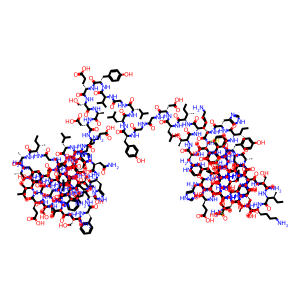

In [10]:
from rdkit import Chem

smiles = smiles_data['smiles'].iloc[1]  # Get the first SMILES string
mol = Chem.MolFromSmiles(smiles)
Chem.Draw.MolToImage(mol)


Lysines in sequence: AKKKA
Lysine SMILES: C[C@H](N)C(=O)N[C@@H](CCCCN)C(=O)N[C@@H](CCCCN)C(=O)N[C@@H](CCCCN)C(=O)N[C@@H](C)C(=O)O


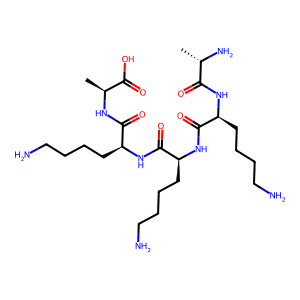

In [19]:
# convert lysing (K) to smiles 
from rdkit import Chem

lysine = 'AKKKA'
print(f"Lysines in sequence: {lysine}")
# Convert the one-letter code for lysine to its SMILES representation
lysine_mol = Chem.MolFromSequence(lysine)
lysine_smiles = Chem.MolToSmiles(lysine_mol)
print(f"Lysine SMILES: {lysine_smiles}")

Chem.Draw.MolToImage(lysine_mol)


C=CCCCCC(C)CCCCCC#CCCC(OC)C(=O)OC(=O)C(CCC#CCCCCCC(C)CCCCC=C)OC


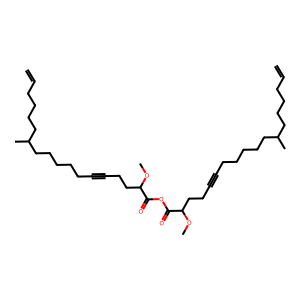

In [ ]:
# load LMSD.smiles using pandas
import pandas as pd

lmsd_data = pd.read_csv('LMSD_clean.smiles', header=None, names=['smiles'])
# print the first 5 rows
print(lmsd_data['smiles'][1])

# draw the first molecule using RDKit
from rdkit import Chem
mol = Chem.MolFromSmiles(lmsd_data['smiles'][1])
Chem.Draw.MolToImage(mol)


In [ ]:
# load several SMILES files and concatenate them
import pandas as pd

# List of SMILES files to load
smiles_files = [
    'ESMAtlas_clust30_clean.smiles',
    'LMSD_clean.smiles',
    'smprot_all.protracted.smiles',
    'PubChem_clean.smiles',
    'PeptideCLM_random.smiles'
]

# Load each file (remove first line if it is 'smiles' and concatenate them into a single DataFrame
# add a column for the smiles_files name

smiles_data = pd.concat(
    [pd.read_csv(file, header=None, names=['smiles']).assign(source=file) for file in smiles_files],
    ignore_index=True
)
# print the first 5 rows of the concatenated DataFrame
print(smiles_data.head())
print(len(smiles_data)) # Check the number of rows loaded

# remove any rows with 'smiles' as the smiles string
smiles_data = smiles_data[smiles_data['smiles'] != 'smiles']
print(len(smiles_data)) # check number of rows after removing 'smiles'; should be 2 less



                                              smiles  \
0  CC[C@H](C)[C@H](NC(=O)[C@H](CC(=O)O)NC(=O)[C@H...   
1  CC[C@H](C)[C@H](NC(=O)CNC(=O)[C@H](CCCCN)NC(=O...   
2  CC[C@H](C)[C@H](NC(=O)[C@H](CC(=O)O)NC(=O)[C@H...   
3  CC[C@H](C)[C@H](NC(=O)[C@H](C)NC(=O)[C@@H]1CCC...   
4  CC[C@H](C)[C@H](NC(=O)[C@H](CC(=O)O)NC(=O)[C@H...   

                          source  
0  ESMAtlas_clust30_clean.smiles  
1  ESMAtlas_clust30_clean.smiles  
2  ESMAtlas_clust30_clean.smiles  
3  ESMAtlas_clust30_clean.smiles  
4  ESMAtlas_clust30_clean.smiles  
149351858
                                                      smiles  \
0          CC[C@H](C)[C@H](NC(=O)[C@H](CC(=O)O)NC(=O)[C@H...   
1          CC[C@H](C)[C@H](NC(=O)CNC(=O)[C@H](CCCCN)NC(=O...   
2          CC[C@H](C)[C@H](NC(=O)[C@H](CC(=O)O)NC(=O)[C@H...   
3          CC[C@H](C)[C@H](NC(=O)[C@H](C)NC(=O)[C@@H]1CCC...   
4          CC[C@H](C)[C@H](NC(=O)[C@H](CC(=O)O)NC(=O)[C@H...   
...                                                      ..

In [4]:
smiles_data['source'].value_counts()

source
PubChem_clean.smiles             121401411
PeptideCLM_random.smiles          10000000
ESMAtlas_clust30_clean.smiles      9634945
smprot_all.protracted.smiles       8254200
LMSD_clean.smiles                    49145
Name: count, dtype: int64

In [ ]:
# save to parquet
smiles_data['source'].value_counts()
smiles_data.to_parquet('ARVF_all_smiles_data.parquet', index=False)


In [2]:
import pandas as pd
# load from parquet
smiles_data_loaded = pd.read_parquet('ARVF_all_smiles_data.parquet')
# print(smiles_data_loaded.head())
print(len(smiles_data_loaded))  # Check the number of rows loaded

149339701


In [ ]:
pubchem_smiles = smiles_data_loaded[smiles_data_loaded['source']=='PubChem_clean.smiles'].head()
len(pubchem_smiles)


In [ ]:
from rdkit import Chem
from rdkit.Chem import Descriptors
import numpy as np

def smiles_to_rdkit(smiles):
    mol = Chem.MolFromSmiles(smiles)
    desc_values = [float(x[1](mol)) for x in Descriptors._descList if x[0]!='Ipc']
    return np.array(desc_values)

test_smiles = 'CC[C@H](C)[C@H](NC(=O)[C@H](CC(=O)O)NC(=O)[C@H](Cc1ccccc1)NC(=O)[C@H](CC(N)=O)NC(=O)[C@H](CCCCN)NC(=O)[C@H](CC(=O)O)NC(=O)[C@H](CC(=O)O)NC(=O)[C@@H]1CCCN1C(=O)[C@@H](NC(=O)[C@H](CC(N)=O)NC(=O)[C@H](CO)NC(=O)[C@@H](N)CCSC)[C@@H](C)O)C(=O)N[C@@H](C)C(=O)NCC(=O)N[C@@H](Cc1ccccc1)C(=O)N[C@@H](CC(C)C)C(=O)N[C@@H](CC(C)C)C(=O)N[C@@H](C)C(=O)NCC(=O)N[C@@H](CC(N)=O)C(=O)N[C@H](C(=O)N[C@@H](CCSC)C(=O)N[C@H](C(=O)N[C@@H](CCCCN)C(=O)N[C@@H](CC(C)C)C(=O)N[C@H](C(=O)N[C@@H](CCC(=O)O)C(=O)N[C@@H](CCCCN)C(=O)NCC(=O)N[C@H](C(=O)N[C@H](C(=O)N[C@@H](CC(=O)O)C(=O)N[C@@H](CCSC)C(=O)N[C@@H](CCCNC(=N)N)C(=O)N[C@@H](CC(=O)O)C(=O)N[C@@H](C)C(=O)N[C@@H](CC(N)=O)C(=O)N[C@@H](CC(=O)O)C(=O)N[C@H](C(=O)N[C@H](C(=O)N[C@@H](C)C(=O)N[C@@H](CCCNC(=N)N)C(=O)N[C@H](C(=O)N[C@@H](CCCNC(=N)N)C(=O)N[C@@H](C)C(=O)N[C@@H](C)C(=O)N[C@@H](Cc1ccc(O)cc1)C(=O)N[C@H](C(=O)N[C@@H](CCC(N)=O)C(=O)N[C@@H](CCCNC(=N)N)C(=O)N[C@@H](CC(=O)O)C(=O)N[C@@H](CO)C(=O)N[C@@H](Cc1ccc(O)cc1)C(=O)N[C@@H](CCCCN)C(=O)N[C@@H](CC(=O)O)C(=O)N[C@@H](CCC(=O)O)C(=O)N[C@@H](CO)C(=O)N[C@@H](CC(C)C)C(=O)NCC(=O)N[C@@H](CO)C(=O)N[C@@H](CC(=O)O)C(=O)N[C@@H](C)C(=O)N[C@@H](CCC(=O)O)C(=O)N[C@@H](C)C(=O)N[C@@H](Cc1ccc(O)cc1)C(=O)N[C@@H](CC(C)C)C(=O)N[C@@H](CC(=O)O)C(=O)N[C@H](C(=O)N[C@@H](CC(C)C)C(=O)N[C@@H](Cc1ccccc1)C(=O)N[C@@H](CC(N)=O)C(=O)N[C@@H](CCCCN)C(=O)N[C@@H](CC(C)C)C(=O)N[C@@H](Cc1c[nH]c2ccccc12)C(=O)N[C@@H](C)C(=O)N[C@@H](CO)C(=O)N[C@@H](CCCNC(=N)N)C(=O)N1CCC[C@H]1C(=O)N[C@@H](CC(=O)O)C(=O)N[C@@H](C)C(=O)N[C@H](C(=O)NCC(=O)N[C@@H](CCCCN)C(=O)N[C@@H](CCCCN)C(=O)O)C(C)C)[C@@H](C)O)[C@@H](C)O)[C@@H](C)O)C(C)C)[C@@H](C)CC)[C@@H](C)CC)C(C)C)C(C)C)C(C)C)[C@@H](C)CC'

descriptors_test = smiles_to_rdkit(test_smiles)


In [13]:
len(descriptors_test)

216

In [ ]:
from rdkit import Chem
from rdkit.Chem import AllChem
from rdkit.Chem import Descriptors
from rdkit.Chem import rdFingerprintGenerator
import numpy as np
from torch.utils.data import Dataset
import torch
from transformers import AutoTokenizer, AutoModelForMaskedLM
from torch import nn

def smiles_to_fingerprints(smiles, radius=3, nBits=1024):
    gen = rdFingerprintGenerator.GetMorganGenerator(radius=radius, fpSize=nBits)
    mol = Chem.MolFromSmiles(smiles)
    fp = gen.GetFingerprint(mol)
    fingerprint = np.array(fp,dtype=np.float32)
    return fingerprint
 
def smiles_to_rdkit(smiles):
    mol = Chem.MolFromSmiles(smiles)
    desc_values = [float(x[1](mol)) for x in Chem.Descriptors._descList if x[0]!='Ipc']
    return np.array(desc_values)
 
def smiles_to_chemberta(smiles):
    tokenizer = AutoTokenizer.from_pretrained("DeepChem/ChemBERTa-77M-MTR")
    model = AutoModelForMaskedLM.from_pretrained("DeepChem/ChemBERTa-77M-MTR")
    tokenizer.vocab
    smiles_string = "CCCCC"
    tokens = tokenizer(smiles_string, return_tensors="pt")
    outputs = model(**tokens, return_dict=True, output_hidden_states=True)
    return  outputs.hidden_states[-1].squeeze(0).detach().numpy()  
 
class CustomDataset(Dataset):
    def __init__(self, X, y):
        self.X = X
        self.y = y
 
    def __len__(self):
        return len(self.X)
 
    def __getitem__(self, idx):
        # inputs = torch.tensor(smiles_to_fingerprints(self.X[idx]), dtype=torch.float32)
        inputs = torch.tensor(smiles_to_rdkit(self.X[idx]), dtype=torch.float32)
        labels = torch.tensor(self.y[idx], dtype=torch.float32)
        return inputs, labels

class MLP(nn.Module):
    def __init__(self, input_dim=1024, hidden_dim=512):
        super(MLP, self).__init__()
        self.layers = nn.Sequential(
            nn.Linear(input_dim, hidden_dim), nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim), nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim), nn.ReLU(),
            nn.Linear(hidden_dim, 1)
        )
    
    def forward(self, x):
        return self.layers(x)
 

CC(C)CC(=O)O CC(C)CC(O)=O


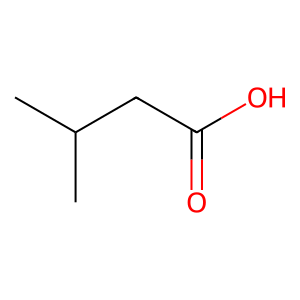

In [36]:
from rdkit import Chem

# Convert a molecule to SMILES with randomization
smiles_test = 'CC(C)CC(=O)O'

mol = Chem.MolFromSmiles(smiles_test)
smile = Chem.MolToSmiles(mol, isomericSmiles=True, doRandom=True)
canon_smile = Chem.MolToSmiles(mol, isomericSmiles=True, doRandom=False, canonical=True)

print(canon_smile, smile)

Chem.Draw.MolToImage(Chem.MolFromSmiles(smile))

In [6]:
import re

def clean_file(input_file, output_file):
    def clean_smiles(smiles):
        smiles = re.sub(r'\.\[[^\]]+\]', '', smiles)  
        smiles = re.sub(r'\.([A-Za-z0-9_]+)\.\1', '', smiles)
        smiles = re.sub(r'^(Cl\.|Br\.|\.Cl|\.Br)', '', smiles)
        smiles = re.sub(r'(Cl\.|Br\.|\.Cl|\.Br)$', '', smiles)
        smiles = re.sub(r'(Cl\.|Br\.){2,}', '', smiles)
        return smiles.strip()

    # Read input, clean, and split data, then remove duplicates
    all_sections = set()  # Using a set to handle duplicates

    with open(input_file, 'r') as infile:
        for line in infile:
            cleaned_line = clean_smiles(line)  # Clean the line
            sections = cleaned_line.split('.')  # Split on periods
            for section in sections:
                all_sections.add(section.strip())  # Add to set to ensure uniqueness

    # Write results to output file
    with open(output_file, 'w') as outfile:
        for section in sorted(all_sections):  # Sort for consistency
            if section:  # Avoid writing empty lines
                outfile.write(section + '\n')

# Call the function to clean the file
clean_file('PubChem_clean.smiles', 'PubChem_clean2.smiles')

In [7]:
# filter PubChem_clean2.smiles to remove any lines that are less than 20 characters long
def filter_smiles(input_file, output_file, min_length=20):
    with open(input_file, 'r') as infile, open(output_file, 'w') as outfile:
        for line in infile:
            if len(line.strip()) >= min_length:
                outfile.write(line)
# Call the function to filter the file
filter_smiles('PubChem_clean2.smiles', 'PubChem_clean3.smiles')


In [10]:
# find the longest five lines in PubChem_clean3.smiles
def find_longest_lines(input_file):
    longest_lines = []
    with open(input_file, 'r') as infile:
        for line in infile:
            line = line.strip()
            if len(longest_lines) < 5:
                longest_lines.append(line)
                longest_lines.sort(key=len, reverse=True)
            elif len(line) > len(longest_lines[-1]):
                longest_lines[-1] = line
                longest_lines.sort(key=len, reverse=True)
    return longest_lines

def find_longest_line(input_file):
    longest_line = ''
    with open(input_file, 'r') as infile:
        for line in infile:
            line = line.strip()
            if len(line) > len(longest_line):
                longest_line = line
    return longest_line

# Call the function to find the longest five lines
longest_lines = find_longest_lines('PubChem_clean3.smiles')

print("The longest five lines in PubChem_clean3.smiles are:")
for i, line in enumerate(longest_lines, 1):
    print(f"{i}: {line}\nLength: {len(line)} characters")


The longest five lines in PubChem_clean3.smiles are:
1: C[Si](C)(O)O[Si](=O)[Si](=O)[Si](=O)[Si](=O)[Si](=O)[Si](=O)[Si](=O)[Si](=O)[Si](=O)[Si](=O)[Si](=O)[Si](=O)[Si](=O)[Si](=O)[Si](=O)[Si](=O)[Si](=O)[Si](=O)[Si](=O)[Si](=O)[Si](=O)[Si](=O)[Si](=O)[Si](=O)[Si](=O)[Si](=O)[Si](=O)[Si](=O)[Si](=O)[Si](=O)[Si](=O)[Si](=O)[Si](=O)[Si](=O)[Si](=O)[Si](=O)[Si](=O)[Si](=O)[Si](=O)[Si](=O)[Si](=O)[Si](=O)[Si](=O)[Si](=O)[Si](=O)[Si](=O)[Si](=O)[Si](=O)[Si](=O)[Si](=O)[Si](=O)[Si](=O)[Si](=O)[Si](=O)[Si](=O)[Si](=O)[Si](=O)[Si](=O)[Si](=O)[Si](=O)[Si](=O)[Si](=O)[Si](=O)[Si](=O)[Si](=O)[Si](=O)[Si](=O)[Si](=O)[Si](=O)[Si](=O)[Si](=O)[Si](=O)[Si](=O)[Si](=O)[Si](=O)[Si](=O)[Si](=O)[Si](=O)[Si](=O)[Si](=O)[Si](=O)[Si](=O)[Si](=O)[Si](=O)[Si](=O)[Si](=O)[Si](=O)[Si](=O)[Si](=O)[Si](=O)[Si](=O)[Si](=O)[Si](=O)[Si](=O)[Si](=O)[Si](=O)[Si](=O)[Si](=O)[Si](=O)[Si](=O)[Si](=O)[Si](=O)[Si](=O)[Si](=O)[Si](=O)[Si](=O)[Si](=O)[Si](=O)[Si](=O)[Si](=O)[Si](=O)[Si](=O)[Si](=O)[Si](=O)[Si](=O)[Si](=O)[Si]

In [9]:
# find average line length in PubChem_clean3.smiles
def average_line_length(input_file):
    total_length = 0
    line_count = 0
    with open(input_file, 'r') as infile:
        for line in infile:
            total_length += len(line)
            line_count += 1
    return total_length / line_count if line_count > 0 else 0
# Call the function to find the average line length
avg_length = average_line_length('PubChem_clean3.smiles')
print(f"The average line length in PubChem_clean3.smiles is: {avg_length:.2f} characters")


The average line length in PubChem_clean3.smiles is: 50.92 characters


In [11]:
# remove lines with "[Si](=O)[Si](=O)[Si](=O)[Si](=O)"
def remove_silicon_lines(input_file, output_file):
    with open(input_file, 'r') as infile, open(output_file, 'w') as outfile:
        for line in infile:
            if "[Si](=O)[Si](=O)[Si](=O)[Si](=O)" not in line:
                outfile.write(line)

# Call the function to remove silicon lines
remove_silicon_lines('PubChem_clean3.smiles', 'PubChem_clean4.smiles')

# find the longest line in PubChem_clean4.smiles
longest_line = find_longest_line('PubChem_clean4.smiles')
print(f"The longest line in PubChem_clean4.smiles is:\n{longest_line}\nLength: {len(longest_line)} characters")



The longest line in PubChem_clean4.smiles is:
[2H]c1c([2H])c(-c2c([2H])c3c([2H])c([2H])c([2H])c([2H])c3c3c([2H])c([2H])c([2H])c([2H])c23)c([2H])c([2H])c1-c1c2c([2H])c([2H])c([2H])c([2H])c2c(-c2c([2H])c([2H])c([2H])c3c([2H])c([2H])c([2H])c([2H])c23)c2c([2H])c([2H])c([2H])c([2H])c12c1c([2H])c(-c2c3c([2H])c([2H])c([2H])c([2H])c3c(-c3c([2H])c([2H])c([2H])c4c([2H])c([2H])c([2H])c([2H])c34)c3c([2H])c([2H])c([2H])c([2H])c23)c([2H])c([2H])c1-c1c([2H])c([2H])c2c(c1[2H])c([2H])c([2H])c1c([2H])c([2H])c([2H])c([2H])c12c1c([2H])c(-c2c3c([2H])c([2H])c([2H])c([2H])c3c(-c3c([2H])c([2H])c4c([2H])c([2H])c([2H])c([2H])c4c3[2H])c3c([2H])c([2H])c([2H])c([2H])c23)c([2H])c([2H])c1-c1c([2H])c([2H])c2c(c1[2H])c([2H])c([2H])c1c([2H])c([2H])c([2H])c([2H])c12c1c([2H])c([2H])c(-c2c([2H])c([2H])c(-c3c4c([2H])c([2H])c([2H])c([2H])c4c(-c4c([2H])c([2H])c([2H])c5c([2H])c([2H])c([2H])c([2H])c45)c4c([2H])c([2H])c([2H])c([2H])c34)c([2H])c2[2H])c([2H])c1[2H]c1c([2H])c([2H])c(-c2c([2H])c([2H])c([2H])c(-c3c4c([2H])c([2H])c([

In [12]:
# load several SMILES files and concatenate them
import pandas as pd

# List of SMILES files to load
smiles_files = [
    'ESMAtlas_clust30_clean.smiles',
    'LMSD_clean.smiles',
    'smprot_all.protracted.smiles',
    'PubChem_clean4.smiles',
    'PeptideCLM_random.smiles'
]

# Load each file (remove first line if it is 'smiles' and concatenate them into a single DataFrame
# add a column for the smiles_files name

smiles_data = pd.concat(
    [pd.read_csv(file, header=None, names=['smiles']).assign(source=file) for file in smiles_files],
    ignore_index=True
)

# remove any rows with 'smiles' as the smiles string
smiles_data = smiles_data[smiles_data['smiles'] != 'smiles']
print(len(smiles_data)) # check number of rows after removing 'smiles'; should be 2 less


print(smiles_data['source'].value_counts())

smiles_data.to_parquet('ARVF_all_smiles_data2.parquet', index=False)


136521447
source
PubChem_clean4.smiles            108583157
PeptideCLM_random.smiles          10000000
ESMAtlas_clust30_clean.smiles      9634945
smprot_all.protracted.smiles       8254200
LMSD_clean.smiles                    49145
Name: count, dtype: int64


In [1]:
import pandas as pd
smiles_data = pd.read_parquet('ARVF_all_smiles_data2.parquet')


/tmp/ipykernel_2675421/153820572.py:5: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  smiles_sampled = smiles_data.groupby('source').apply(lambda x: x.sample(frac=0.01, random_state=42)).reset_index(drop=True)


                                                    smiles  \
0        CC[C@H](C)[C@H](NC(=O)[C@H](CC(N)=O)NC(=O)[C@@...   
1        CC[C@H](C)[C@H](NC(=O)[C@H](C)NC(=O)[C@H](CC(=...   
2        CC[C@H](C)[C@H](NC(=O)[C@H](Cc1ccc(O)cc1)NC(=O...   
3        CSCC[C@H](N)C(=O)N[C@@H](CO)C(=O)N[C@@H](CC(=O...   
4        CC[C@H](C)[C@H](NC(=O)[C@H](CO)NC(=O)[C@H](CC(...   
...                                                    ...   
2039640  CC[C@H](C)[C@H](NC(=O)[C@H](CC(N)=O)NC(=O)[C@H...   
2039641  CC[C@H](C)[C@H](NC(=O)[C@H](CC(N)=O)NC(=O)[C@H...   
2039642  CC[C@H](C)[C@H](NC(=O)[C@H](CC(N)=O)NC(=O)[C@H...   
2039643  CSCC[C@H](N)C(=O)N[C@H](C(=O)N[C@@H](CCC(N)=O)...   
2039644  CC[C@H](C)[C@H](NC(=O)[C@H](C)NC(=O)[C@H](C)NC...   

                                source  
0        ESMAtlas_clust30_clean.smiles  
1        ESMAtlas_clust30_clean.smiles  
2        ESMAtlas_clust30_clean.smiles  
3        ESMAtlas_clust30_clean.smiles  
4        ESMAtlas_clust30_clean.smiles  
...      

In [3]:
smiles_data['source'].value_counts()


source
PubChem_clean4.smiles            108583157
PeptideCLM_random.smiles          10000000
ESMAtlas_clust30_clean.smiles      9634945
smprot_all.protracted.smiles       8254200
LMSD_clean.smiles                    49145
Name: count, dtype: int64

In [5]:
smiles_data['split'] = 'train'  # Default split

# asign 'test' split to 1% of the data per source
for source in smiles_data['source'].unique():
    source_indices = smiles_data[smiles_data['source'] == source].index
    if source not in ['PubChem_clean4.smiles']:
        test_indices = smiles_data.loc[source_indices].sample(frac=0.01, random_state=42).index
    else:
        test_indices = smiles_data.loc[source_indices].sample(frac=0.001, random_state=42).index
    smiles_data.loc[test_indices, 'split'] = 'test'

# count split values per source
split_counts = smiles_data.groupby(['source', 'split']).size().unstack(fill_value=0)
print(split_counts)

split                            test      train
source                                          
ESMAtlas_clust30_clean.smiles   96349    9538596
LMSD_clean.smiles                 491      48654
PeptideCLM_random.smiles       100000    9900000
PubChem_clean4.smiles          108583  108474574
smprot_all.protracted.smiles    82542    8171658


In [6]:
# save the updated DataFrame to a new parquet file
smiles_data.to_parquet('ARVF_all_smiles_data_split.parquet', index=False)


In [7]:
# read the updated DataFrame from the parquet file
smiles_data_split = pd.read_parquet('ARVF_all_smiles_data_split.parquet')

len(smiles_data_split)

136521447

In [9]:
smiles_data_split['source'].value_counts()

source
PubChem_clean4.smiles            108583157
PeptideCLM_random.smiles          10000000
ESMAtlas_clust30_clean.smiles      9634945
smprot_all.protracted.smiles       8254200
LMSD_clean.smiles                    49145
Name: count, dtype: int64

In [ ]:
from rdkit import Chem
import pandas as pd

smiles_data_split = pd.read_parquet('ARVF_all_smiles_data_split.parquet')

# for all rows, try to convert the smiles to a mol and back to canonical smiles
count_of_errors = 0

def canonicalize_smiles(smiles):
    try:
        mol = Chem.MolFromSmiles(smiles)
        if mol:
            return Chem.MolToSmiles(mol, isomericSmiles=True, canonical=True)
    except Exception as e:
        count_of_errors += 1
    return None

smiles_data_split['canonical_smiles'] = smiles_data_split['smiles'].apply(canonicalize_smiles)



In [20]:
# read the updated DataFrame from the parquet file
smiles_data_split = pd.read_parquet('ARVF_all_smiles_data_split_canonical.parquet')

print(len(smiles_data_split))

# value count of 'split' per source
split_counts = smiles_data_split.groupby(['source', 'split']).size().unstack(fill_value=0)
print(split_counts)

136162528
split                            test      train
source                                          
ESMAtlas_clust30_clean.smiles   96349    9538596
LMSD_clean.smiles                 491      48654
PeptideCLM_random.smiles       100000    9900000
PubChem_clean4.smiles          108191  108116047
smprot_all.protracted.smiles    82542    8171658


In [21]:
# get average length of smiles per source
smiles_data_split['smiles_length'] = smiles_data_split['smiles'].apply(len)
average_smiles_length = smiles_data_split.groupby('source')['smiles_length'].mean()
print(average_smiles_length)

source
ESMAtlas_clust30_clean.smiles    1147.758172
LMSD_clean.smiles                 106.104853
PeptideCLM_random.smiles         1042.599268
PubChem_clean4.smiles              49.623917
smprot_all.protracted.smiles      933.962574
Name: smiles_length, dtype: float64


In [22]:
# do overall average smiles length
overall_average_length = smiles_data_split['smiles_length'].mean()
print(f"Overall average SMILES length: {overall_average_length:.2f} characters")

Overall average SMILES length: 253.88 characters


In [23]:
# take a sample from each source and encode it with tokenizer, take the average length of the encoded tokens
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained("aaronfeller/PeptideMTR")

def average_token_length(smiles_series):
    tokenized = tokenizer(smiles_series.tolist(), padding=True, truncation=True, return_tensors='pt')
    return tokenized.input_ids.shape[1]

# for 10,000 from each source, take the average token length
sampled_smiles = smiles_data_split.groupby('source').apply(lambda x: x.sample(n=10000, random_state=42)).reset_index(drop=True)

# print average string length for sampled_smiles
sampled_smiles['smiles_length'] = sampled_smiles['smiles'].apply(len)
average_sampled_length = sampled_smiles.groupby('source')['smiles_length'].mean()
print("Average SMILES lengths for sampled data:")
print(average_sampled_length)

average_token_lengths = sampled_smiles.groupby('source')['smiles'].apply(average_token_length)
print("Average token lengths per source:")
print(average_token_lengths)


/dcai/projects02/cu_0001/users/arvf/novo_clm/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/tmp/ipykernel_2675421/3997942989.py:11: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  sampled_smiles = smiles_data_split.groupby('source').apply(lambda x: x.sample(n=10000, random_state=42)).reset_index(drop=True)


Average SMILES lengths for sampled data:
source
ESMAtlas_clust30_clean.smiles    1149.8972
LMSD_clean.smiles                 108.0800
PeptideCLM_random.smiles         1060.5218
PubChem_clean4.smiles              49.5845
smprot_all.protracted.smiles      931.9130
Name: smiles_length, dtype: float64
Average token lengths per source:
source
ESMAtlas_clust30_clean.smiles    600
LMSD_clean.smiles                315
PeptideCLM_random.smiles         697
PubChem_clean4.smiles            369
smprot_all.protracted.smiles     727
Name: smiles, dtype: int64


In [33]:
lmsd_smiles = sampled_smiles[sampled_smiles['source']=='LMSD_clean.smiles']

length_sum = 0
for smiles in lmsd_smiles['smiles']:
    tokenized = tokenizer(smiles, padding=True, truncation=True, return_tensors='pt')
    # print(f"SMILES: {smiles}")
    # print(f"Tokenized input IDs: {tokenized.input_ids}")
    # print(f"Number of tokens: {tokenized.input_ids.shape[1]}")
    length_sum += tokenized.input_ids.shape[1]

average_length = length_sum / 10000
print(f"Average token length for the first 10 SMILES in LMSD: {average_length:.2f} tokens")



Average token length for the first 10 SMILES in LMSD: 39.92 tokens


In [34]:

for source in sampled_smiles['source'].unique():
    print(f"Processing source: {source}")
    source_smiles = sampled_smiles[sampled_smiles['source'] == source]
    
    smiles_length = 0
    length_sum = 0
    for smiles in source_smiles['smiles']:
        tokenized = tokenizer(smiles, padding=True, truncation=True, return_tensors='pt')
        # print(f"SMILES: {smiles}")
        # print(f"Tokenized input IDs: {tokenized.input_ids}")
        # print(f"Number of tokens: {tokenized.input_ids.shape[1]}")
        length_sum += tokenized.input_ids.shape[1]
        smiles_length += len(smiles)
    
    average_smiles_length = smiles_length / 10000
    print(f"Average SMILES length for {source}: {average_smiles_length:.2f} characters\n")

    average_length = length_sum / 10000
    print(f"Average token length for {source}: {average_length:.2f} tokens")

    compression_ratio = average_length / average_smiles_length
    print(f"Compression ratio for {source}: {compression_ratio:.2f}\n")

Processing source: ESMAtlas_clust30_clean.smiles
Average SMILES length for ESMAtlas_clust30_clean.smiles: 1149.90 characters

Average token length for ESMAtlas_clust30_clean.smiles: 312.24 tokens
Compression ratio for ESMAtlas_clust30_clean.smiles: 0.27

Processing source: LMSD_clean.smiles
Average SMILES length for LMSD_clean.smiles: 108.08 characters

Average token length for LMSD_clean.smiles: 39.92 tokens
Compression ratio for LMSD_clean.smiles: 0.37

Processing source: PeptideCLM_random.smiles
Average SMILES length for PeptideCLM_random.smiles: 1060.52 characters

Average token length for PeptideCLM_random.smiles: 317.95 tokens
Compression ratio for PeptideCLM_random.smiles: 0.30

Processing source: PubChem_clean4.smiles
Average SMILES length for PubChem_clean4.smiles: 49.58 characters

Average token length for PubChem_clean4.smiles: 25.45 tokens
Compression ratio for PubChem_clean4.smiles: 0.51

Processing source: smprot_all.protracted.smiles
Average SMILES length for smprot_all.

In [44]:
token_lengths = [312, 40, 318, 25, 254]
factors_per_epoch = [9.5, 0.05, 1, 10, 8.2]

# multiply each token length by the corresponding factor
adjusted_token_lengths = [token_length * factor for token_length, factor in zip(token_lengths, factors_per_epoch)]
print(sum(adjusted_token_lengths)*1_000_000/1_000_000_000,'billion tokens per epoch')


5.616799999999999 billion tokens per epoch


In [ ]:
from rdkit import Chem
from rdkit.Chem import Descriptors
import numpy as np


def smiles_to_rdkit(smiles):
    mol = Chem.MolFromSmiles(smiles)
    desc_values = [float(x[1](mol)) for x in Descriptors._descList if x[0]!='Ipc']
    return np.array(desc_values)

smile = 'CC(C)CC(=O)O'

rdkit_stuff = smiles_to_rdkit(smile)

len(rdkit_stuff)

array([  9.80972222,   9.80972222,   0.27546296,  -0.71296296,
         0.56681892,   9.57142857, 102.133     ,  92.053     ,
       102.06807956,  42.        ,   0.        ,   0.30310055,
        -0.48122306,   0.48122306,   0.30310055,   1.71428571,
         2.14285714,   2.14285714,  16.36519457,  10.14230095,
         1.97926876,  -1.93827813,   1.96031264,  -1.98654564,
         5.66322331,  -0.1373176 ,   1.2729056 ,   3.12600665,
        66.48040588,   5.86180732,   4.63991894,   4.63991894,
         3.12589766,   2.34423316,   2.34423316,   1.99170954,
         1.99170954,   0.58286872,   0.58286872,   0.34924085,
         0.34924085,  -0.53      ,   6.47      ,   2.61092148,
         5.47      ,  43.15477534,   5.10652739,   0.        ,
         0.        ,   0.        ,   0.        ,   5.96930529,
         4.79453718,   0.        ,   0.        ,   0.        ,
        13.8474744 ,   5.91790605,   6.42082162,   0.        ,
         9.90106458,   5.96930529,   0.        ,   0.  

In [1]:
from rdkit.Chem import Descriptors
print(f"Current descriptor count: {len(Descriptors._descList)}")
# Print descriptor names
for desc in Descriptors._descList:
    print(desc[0])

Current descriptor count: 217
MaxAbsEStateIndex
MaxEStateIndex
MinAbsEStateIndex
MinEStateIndex
qed
SPS
MolWt
HeavyAtomMolWt
ExactMolWt
NumValenceElectrons
NumRadicalElectrons
MaxPartialCharge
MinPartialCharge
MaxAbsPartialCharge
MinAbsPartialCharge
FpDensityMorgan1
FpDensityMorgan2
FpDensityMorgan3
BCUT2D_MWHI
BCUT2D_MWLOW
BCUT2D_CHGHI
BCUT2D_CHGLO
BCUT2D_LOGPHI
BCUT2D_LOGPLOW
BCUT2D_MRHI
BCUT2D_MRLOW
AvgIpc
BalabanJ
BertzCT
Chi0
Chi0n
Chi0v
Chi1
Chi1n
Chi1v
Chi2n
Chi2v
Chi3n
Chi3v
Chi4n
Chi4v
HallKierAlpha
Ipc
Kappa1
Kappa2
Kappa3
LabuteASA
PEOE_VSA1
PEOE_VSA10
PEOE_VSA11
PEOE_VSA12
PEOE_VSA13
PEOE_VSA14
PEOE_VSA2
PEOE_VSA3
PEOE_VSA4
PEOE_VSA5
PEOE_VSA6
PEOE_VSA7
PEOE_VSA8
PEOE_VSA9
SMR_VSA1
SMR_VSA10
SMR_VSA2
SMR_VSA3
SMR_VSA4
SMR_VSA5
SMR_VSA6
SMR_VSA7
SMR_VSA8
SMR_VSA9
SlogP_VSA1
SlogP_VSA10
SlogP_VSA11
SlogP_VSA12
SlogP_VSA2
SlogP_VSA3
SlogP_VSA4
SlogP_VSA5
SlogP_VSA6
SlogP_VSA7
SlogP_VSA8
SlogP_VSA9
TPSA
EState_VSA1
EState_VSA10
EState_VSA11
EState_VSA2
EState_VSA3
EState_VSA4
E

In [ ]:
descriptors_list = ['BalabanJ', 'BertzCT', 'Chi0', 'Chi0n', 'Chi0v', 'Chi1', 'Chi1n',
    'Chi1v', 'Chi2n', 'Chi2v', 'Chi3n', 'Chi3v', 'Chi4n', 'Chi4v',
    'EState_VSA1', 'EState_VSA10', 'EState_VSA11', 'EState_VSA2',
    'EState_VSA3', 'EState_VSA4', 'EState_VSA5', 'EState_VSA6',
    'EState_VSA7', 'EState_VSA8', 'EState_VSA9', 'ExactMolWt',
    'FpDensityMorgan1', 'FpDensityMorgan2', 'FpDensityMorgan3',
    'FractionCSP3', 'HallKierAlpha', 'HeavyAtomCount', 'HeavyAtomMolWt',
    'Ipc', 'Kappa1', 'Kappa2', 'Kappa3', 'LabuteASA', 'MaxAbsEStateIndex',
    'MaxAbsPartialCharge', 'MaxEStateIndex', 'MaxPartialCharge',
    'MinAbsEStateIndex', 'MinAbsPartialCharge', 'MinEStateIndex',
    'MinPartialCharge', 'MolLogP', 'MolMR', 'MolWt', 'NHOHCount',
    'NOCount', 'NumAliphaticCarbocycles', 'NumAliphaticHeterocycles',
    'NumAliphaticRings', 'NumAromaticCarbocycles', 'NumAromaticHeterocycles',
    'NumAromaticRings', 'NumHAcceptors', 'NumHDonors', 'NumHeteroatoms',
    'NumRadicalElectrons', 'NumRotatableBonds', 'NumSaturatedCarbocycles',
    'NumSaturatedHeterocycles', 'NumSaturatedRings', 'NumValenceElectrons',
    'PEOE_VSA1', 'PEOE_VSA10', 'PEOE_VSA11', 'PEOE_VSA12', 'PEOE_VSA13',
    'PEOE_VSA14', 'PEOE_VSA2', 'PEOE_VSA3', 'PEOE_VSA4', 'PEOE_VSA5',
    'PEOE_VSA6', 'PEOE_VSA7', 'PEOE_VSA8', 'PEOE_VSA9', 'RingCount',
    'SMR_VSA1', 'SMR_VSA10', 'SMR_VSA2', 'SMR_VSA3', 'SMR_VSA4', 'SMR_VSA5',
    'SMR_VSA6', 'SMR_VSA7', 'SMR_VSA8', 'SMR_VSA9', 'SlogP_VSA1', 'SlogP_VSA10',
    'SlogP_VSA11', 'SlogP_VSA12', 'SlogP_VSA2', 'SlogP_VSA3', 'SlogP_VSA4',
    'SlogP_VSA5', 'SlogP_VSA6', 'SlogP_VSA7', 'SlogP_VSA8', 'SlogP_VSA9',
    'TPSA', 'VSA_EState1', 'VSA_EState10', 'VSA_EState2', 'VSA_EState3',
    'VSA_EState4', 'VSA_EState5', 'VSA_EState6', 'VSA_EState7', 'VSA_EState8',
    'VSA_EState9', 'fr_Al_COO', 'fr_Al_OH', 'fr_Al_OH_noTert', 'fr_ArN',
    'fr_Ar_COO', 'fr_Ar_N', 'fr_Ar_NH', 'fr_Ar_OH', 'fr_COO', 'fr_COO2',
    'fr_C_O', 'fr_C_O_noCOO', 'fr_C_S', 'fr_HOCCN', 'fr_Imine', 'fr_NH0',
    'fr_NH1', 'fr_NH2', 'fr_N_O', 'fr_Ndealkylation1', 'fr_Ndealkylation2',
    'fr_Nhpyrrole', 'fr_SH', 'fr_aldehyde', 'fr_alkyl_carbamate', 'fr_alkyl_halide',
    'fr_allylic_oxid', 'fr_amide', 'fr_amidine', 'fr_aniline', 'fr_aryl_methyl',
    'fr_azide', 'fr_azo', 'fr_barbitur', 'fr_benzene', 'fr_benzodiazepine',
    'fr_bicyclic', 'fr_diazo', 'fr_dihydropyridine', 'fr_epoxide', 'fr_ester',
    'fr_ether', 'fr_furan', 'fr_guanido', 'fr_halogen', 'fr_hdrzine', 'fr_hdrzone',
    'fr_imidazole', 'fr_imide', 'fr_isocyan', 'fr_isothiocyan', 'fr_ketone',
    'fr_ketone_Topliss', 'fr_lactam', 'fr_lactone', 'fr_methoxy', 'fr_morpholine',
    'fr_nitrile', 'fr_nitro', 'fr_nitro_arom', 'fr_nitro_arom_nonortho',
    'fr_nitroso', 'fr_oxazole', 'fr_oxime', 'fr_para_hydroxylation', 'fr_phenol',
    'fr_phenol_noOrthoHbond', 'fr_phos_acid', 'fr_phos_ester', 'fr_piperdine',
    'fr_piperzine', 'fr_priamide', 'fr_prisulfonamd', 'fr_pyridine', 'fr_quatN',
    'fr_sulfide', 'fr_sulfonamd', 'fr_sulfone', 'fr_term_acetylene', 'fr_tetrazole',
    'fr_thiazole', 'fr_thiocyan', 'fr_thiophene', 'fr_unbrch_alkane', 'fr_urea', 'qed']

len(descriptors_list)


200

In [7]:
from rdkit import Chem
from rdkit.Chem import Descriptors
import numpy as np


def smiles_to_rdkit(smiles):
    try:
        mol = Chem.MolFromSmiles(smiles)
        desc_values = [float(x[1](mol)) for x in Descriptors._descList if x[0] in descriptors_list]
        return np.array(desc_values)
    except:
        return None


smile = 'CC(C)CC(=O)O'

rdkit_stuff = smiles_to_rdkit(smile)

rdkit_stuff

array([  9.80972222,   9.80972222,   0.27546296,  -0.71296296,
         0.56681892, 102.133     ,  92.053     , 102.06807956,
        42.        ,   0.        ,   0.30310055,  -0.48122306,
         0.48122306,   0.30310055,   1.71428571,   2.14285714,
         2.14285714,   3.12600665,  66.48040588,   5.86180732,
         4.63991894,   4.63991894,   3.12589766,   2.34423316,
         2.34423316,   1.99170954,   1.99170954,   0.58286872,
         0.58286872,   0.34924085,   0.34924085,  -0.53      ,
        19.09358393,   6.47      ,   2.61092148,   5.47      ,
        43.15477534,   5.10652739,   0.        ,   0.        ,
         0.        ,   0.        ,   5.96930529,   4.79453718,
         0.        ,   0.        ,   0.        ,  13.8474744 ,
         5.91790605,   6.42082162,   0.        ,   9.90106458,
         5.96930529,   0.        ,   0.        ,   5.91790605,
        20.26829602,   0.        ,   0.        ,   0.        ,
         0.        ,   0.        ,   0.        ,   0.  

In [ ]:
from rdkit import Chem
from rdkit.Chem import Descriptors
import numpy as np
from functools import partial

# Create a dictionary of descriptor functions once
desc_dict = {name: func for name, func in Descriptors._descList}

# Pre-filter the descriptors you want
desc_funcs = [desc_dict[name] for name in descriptors_list]

def smiles_to_rdkit_fast(smiles):
    """Faster version using pre-filtered descriptor functions"""
    try:
        mol = Chem.MolFromSmiles(smiles)
        if mol is None:
            return None
        return np.array([float(func(mol)) for func in desc_funcs])
    except:
        return None

# For multiple SMILES processing (vectorized approach)
def batch_smiles_to_rdkit(smiles_list):
    """Process multiple SMILES strings efficiently"""
    mols = [Chem.MolFromSmiles(s) for s in smiles_list]
    results = []
    
    for mol in mols:
        if mol is None:
            results.append(None)
            continue
        try:
            desc_values = [float(func(mol)) for func in desc_funcs]
            results.append(desc_values)
        except:
            results.append(None)
    
    return np.array([r for r in results if r is not None])

# Example usage for single SMILES
smile = 'CC(C)CC(=O)O'
rdkit_stuff = smiles_to_rdkit_fast(smile)

# Example usage for multiple SMILES
smiles_list = ['CC(C)CC(=O)O', 'CCO', 'c1ccccc1']
rdkit_stuff_batch = batch_smiles_to_rdkit(smiles_list)


[  3.12600665  66.48040588   5.86180732   4.63991894   4.63991894
   3.12589766   2.34423316   2.34423316   1.99170954   1.99170954
   0.58286872   0.58286872   0.34924085   0.34924085   5.96930529
   4.79453718   0.          12.33872767   0.           0.
   0.           0.          13.8474744    0.           5.10652739
 102.06807956   1.71428571   2.14285714   2.14285714   0.8
  -0.53         7.          92.053       19.09358393   6.47
   2.61092148   5.47        43.15477534   9.80972222   0.48122306
   9.80972222   0.30310055   0.27546296   0.30310055  -0.71296296
  -0.48122306   1.1171      27.0908     102.133        1.
   2.           0.           0.           0.           0.
   0.           0.           1.           1.           2.
   0.           2.           0.           0.           0.
  42.           5.10652739   0.           0.           0.
   0.           5.96930529   4.79453718   0.           0.
   0.          13.8474744    5.91790605   6.42082162   0.
   0.           9.901

In [ ]:
import time
from rdkit import Chem
from rdkit.Chem import Descriptors
import numpy as np

# List of 200 fast descriptors from RDKit
descriptors_list = [#'BalabanJ', 'BertzCT', 
    'Chi0', 'Chi0n', 'Chi0v', 'Chi1', 'Chi1n',
    'Chi1v', 'Chi2n', 'Chi2v', 'Chi3n', 'Chi3v', 'Chi4n', 'Chi4v',
    # 'EState_VSA1', 'EState_VSA10', 'EState_VSA11', 'EState_VSA2',
    # 'EState_VSA3', 'EState_VSA4', 'EState_VSA5', 'EState_VSA6',
    # 'EState_VSA7', 'EState_VSA8', 'EState_VSA9', 
    'ExactMolWt', 'FpDensityMorgan1', 'FpDensityMorgan2', 'FpDensityMorgan3',
    'FractionCSP3', 'HallKierAlpha', 'HeavyAtomCount', 'HeavyAtomMolWt', #'Ipc', 
    'Kappa1', 'Kappa2', 'Kappa3', 'LabuteASA', 
    'MaxAbsPartialCharge', 'MaxPartialCharge', 'MinAbsPartialCharge', 
    # 'MaxEStateIndex', 'MinAbsEStateIndex', 'MinEStateIndex', 'MaxAbsEStateIndex',
    'MinPartialCharge', 'MolLogP', 'MolMR', 'MolWt', 'NHOHCount',
    'NOCount', 'NumAliphaticCarbocycles', 'NumAliphaticHeterocycles',
    'NumAliphaticRings', 'NumAromaticCarbocycles', 'NumAromaticHeterocycles',
    'NumAromaticRings', 'NumHAcceptors', 'NumHDonors', 'NumHeteroatoms',
    'NumRadicalElectrons', 'NumRotatableBonds', 'NumSaturatedCarbocycles',
    'NumSaturatedHeterocycles', 'NumSaturatedRings', 'NumValenceElectrons',
    'PEOE_VSA1', 'PEOE_VSA10', 'PEOE_VSA11', 'PEOE_VSA12', 'PEOE_VSA13',
    'PEOE_VSA14', 'PEOE_VSA2', 'PEOE_VSA3', 'PEOE_VSA4', 'PEOE_VSA5',
    'PEOE_VSA6', 'PEOE_VSA7', 'PEOE_VSA8', 'PEOE_VSA9', 'RingCount',
    'SMR_VSA1', 'SMR_VSA10', 'SMR_VSA2', 'SMR_VSA3', 'SMR_VSA4', 'SMR_VSA5',
    'SMR_VSA6', 'SMR_VSA7', 'SMR_VSA8', 'SMR_VSA9', 'SlogP_VSA1', 'SlogP_VSA10',
    'SlogP_VSA11', 'SlogP_VSA12', 'SlogP_VSA2', 'SlogP_VSA3', 'SlogP_VSA4',
    'SlogP_VSA5', 'SlogP_VSA6', 'SlogP_VSA7', 'SlogP_VSA8', 'SlogP_VSA9',
    'TPSA', 
    # 'VSA_EState1', 'VSA_EState10', 'VSA_EState2', 'VSA_EState3',
    # 'VSA_EState4', 'VSA_EState5', 'VSA_EState6', 'VSA_EState7', 'VSA_EState8',
    # 'VSA_EState9', 
    'fr_Al_COO', 'fr_Al_OH', 'fr_Al_OH_noTert', 'fr_ArN',
    'fr_Ar_COO', 'fr_Ar_N', 'fr_Ar_NH', 'fr_Ar_OH', 'fr_COO', 'fr_COO2',
    'fr_C_O', 'fr_C_O_noCOO', 'fr_C_S', 'fr_HOCCN', 'fr_Imine', 'fr_NH0',
    'fr_NH1', 'fr_NH2', 'fr_N_O', 'fr_Ndealkylation1', 'fr_Ndealkylation2',
    'fr_Nhpyrrole', 'fr_SH', 'fr_aldehyde', 'fr_alkyl_carbamate', 'fr_alkyl_halide',
    'fr_allylic_oxid', 'fr_amide', 'fr_amidine', 'fr_aniline', 'fr_aryl_methyl',
    'fr_azide', 'fr_azo', 'fr_barbitur', 'fr_benzene', 'fr_benzodiazepine',
    'fr_bicyclic', 'fr_diazo', 'fr_dihydropyridine', 'fr_epoxide', 'fr_ester',
    'fr_ether', 'fr_furan', 'fr_guanido', 'fr_halogen', 'fr_hdrzine', 'fr_hdrzone',
    'fr_imidazole', 'fr_imide', 'fr_isocyan', 'fr_isothiocyan', 'fr_ketone',
    'fr_ketone_Topliss', 'fr_lactam', 'fr_lactone', 'fr_methoxy', 'fr_morpholine',
    'fr_nitrile', 'fr_nitro', 'fr_nitro_arom', 'fr_nitro_arom_nonortho',
    'fr_nitroso', 'fr_oxazole', 'fr_oxime', 'fr_para_hydroxylation', 'fr_phenol',
    'fr_phenol_noOrthoHbond', 'fr_phos_acid', 'fr_phos_ester', 'fr_piperdine',
    'fr_piperzine', 'fr_priamide', 'fr_prisulfonamd', 'fr_pyridine', 'fr_quatN',
    'fr_sulfide', 'fr_sulfonamd', 'fr_sulfone', 'fr_term_acetylene', 'fr_tetrazole',
    'fr_thiazole', 'fr_thiocyan', 'fr_thiophene', 'fr_unbrch_alkane', 'fr_urea', 'qed']

test_smiles = []
with open('smprot_all.protracted.smiles', 'r') as f:
    for line in f:
        smile = line.strip()
        test_smiles.append(smile)
        if len(test_smiles) >= 1000:  # Limit to 1,000 SMILES
            break

def smiles_to_rdkit_fast(smiles):
    """Faster version using pre-filtered descriptor functions"""
    try:
        mol = Chem.MolFromSmiles(smiles)
        if mol is None:
            return None
        return np.array([float(func(mol)) for func in desc_funcs])
    except:
        return None

dict_of_times = {}

for descriptor_item in descriptors_list:
    desc_dict = {name: func for name, func in Descriptors._descList if name == descriptor_item}
    desc_funcs = list(desc_dict.values())

    # start timer
    start_time = time.time()
    for smile in test_smiles[0:10]:
        rdkit_stuff = smiles_to_rdkit_fast(smile)
    end_time = time.time()
    elapsed_time = end_time - start_time
    dict_of_times[descriptor_item] = elapsed_time

dict_of_times


{'Chi0': 0.0434267520904541,
 'Chi0n': 0.03351855278015137,
 'Chi0v': 0.03224349021911621,
 'Chi1': 0.05657529830932617,
 'Chi1n': 0.03225970268249512,
 'Chi1v': 0.0322723388671875,
 'Chi2n': 0.06510734558105469,
 'Chi2v': 0.04856371879577637,
 'Chi3n': 0.058145761489868164,
 'Chi3v': 0.05757927894592285,
 'Chi4n': 0.07256412506103516,
 'Chi4v': 0.07257652282714844,
 'ExactMolWt': 0.019582748413085938,
 'FpDensityMorgan1': 0.027956724166870117,
 'FpDensityMorgan2': 0.030973434448242188,
 'FpDensityMorgan3': 0.032831668853759766,
 'FractionCSP3': 0.01950383186340332,
 'HallKierAlpha': 0.0194704532623291,
 'HeavyAtomCount': 0.019423961639404297,
 'HeavyAtomMolWt': 0.019449234008789062,
 'Kappa1': 0.019417524337768555,
 'Kappa2': 0.04652667045593262,
 'Kappa3': 0.05749154090881348,
 'LabuteASA': 0.019817590713500977,
 'MaxAbsPartialCharge': 0.03234362602233887,
 'MaxPartialCharge': 0.032317161560058594,
 'MinAbsPartialCharge': 0.03232455253601074,
 'MinPartialCharge': 0.03226327896118164,

In [12]:
# sort dict_of_times by value
sorted_times = dict(sorted(dict_of_times.items(), key=lambda item: item[1], reverse=True))
# Print sorted times
for descriptor, elapsed_time in sorted_times.items():
    print(f"Descriptor: {descriptor}, Time taken for 10 SMILES: {elapsed_time/10:.4f} seconds.")

# print the sum of all times
total_time = sum(sorted_times.values())
print(f"Total time for all descriptors: {total_time/10:.4f} seconds per molecule.")


Descriptor: qed, Time taken for 10 SMILES: 0.0098 seconds.
Descriptor: Chi4v, Time taken for 10 SMILES: 0.0073 seconds.
Descriptor: Chi4n, Time taken for 10 SMILES: 0.0073 seconds.
Descriptor: Chi2n, Time taken for 10 SMILES: 0.0065 seconds.
Descriptor: Chi3n, Time taken for 10 SMILES: 0.0058 seconds.
Descriptor: Chi3v, Time taken for 10 SMILES: 0.0058 seconds.
Descriptor: Kappa3, Time taken for 10 SMILES: 0.0057 seconds.
Descriptor: Chi1, Time taken for 10 SMILES: 0.0057 seconds.
Descriptor: Chi2v, Time taken for 10 SMILES: 0.0049 seconds.
Descriptor: Kappa2, Time taken for 10 SMILES: 0.0047 seconds.
Descriptor: MolLogP, Time taken for 10 SMILES: 0.0045 seconds.
Descriptor: MolMR, Time taken for 10 SMILES: 0.0045 seconds.
Descriptor: Chi0, Time taken for 10 SMILES: 0.0043 seconds.
Descriptor: Chi0n, Time taken for 10 SMILES: 0.0034 seconds.
Descriptor: FpDensityMorgan3, Time taken for 10 SMILES: 0.0033 seconds.
Descriptor: MaxAbsPartialCharge, Time taken for 10 SMILES: 0.0032 seconds.

In [ ]:
Descriptor: Ipc, Time taken for 10 SMILES: 12.4467 seconds.
Descriptor: Kappa1, Time taken for 10 SMILES: 0.0252 seconds.
Descriptor: Kappa2, Time taken for 10 SMILES: 0.0593 seconds.
Descriptor: Kappa3, Time taken for 10 SMILES: 0.0661 seconds.
Descriptor: LabuteASA, Time taken for 10 SMILES: 0.0192 seconds.
Descriptor: MaxAbsEStateIndex, Time taken for 10 SMILES: 2.5847 seconds.
Descriptor: MaxAbsPartialCharge, Time taken for 10 SMILES: 0.0336 seconds.
Descriptor: MaxEStateIndex, Time taken for 10 SMILES: 2.5765 seconds.
Descriptor: MaxPartialCharge, Time taken for 10 SMILES: 0.0330 seconds.
Descriptor: MinAbsEStateIndex, Time taken for 10 SMILES: 2.5808 seconds.
Descriptor: MinAbsPartialCharge, Time taken for 10 SMILES: 0.0336 seconds.
Descriptor: MinEStateIndex, Time taken for 10 SMILES: 2.5758 seconds.
Descriptor: MinPartialCharge, Time taken for 10 SMILES: 0.0325 seconds.
Descriptor: MolLogP, Time taken for 10 SMILES: 0.0463 seconds.
Descriptor: MolMR, Time taken for 10 SMILES: 0.0442 seconds.
Descriptor: MolWt, Time taken for 10 SMILES: 0.0190 seconds.
Descriptor: NHOHCount, Time taken for 10 SMILES: 0.0191 seconds.
Descriptor: NOCount, Time taken for 10 SMILES: 0.0190 seconds.
Descriptor: NumAliphaticCarbocycles, Time taken for 10 SMILES: 0.0198 seconds.
Descriptor: NumAliphaticHeterocycles, Time taken for 10 SMILES: 0.0208 seconds.
Descriptor: NumAliphaticRings, Time taken for 10 SMILES: 0.0196 seconds.
Descriptor: NumAromaticCarbocycles, Time taken for 10 SMILES: 0.0198 seconds.
Descriptor: NumAromaticHeterocycles, Time taken for 10 SMILES: 0.0198 seconds.
Descriptor: NumAromaticRings, Time taken for 10 SMILES: 0.0193 seconds.
Descriptor: NumHAcceptors, Time taken for 10 SMILES: 0.0219 seconds.
Descriptor: NumHDonors, Time taken for 10 SMILES: 0.0198 seconds.
Descriptor: NumHeteroatoms, Time taken for 10 SMILES: 0.0200 seconds.
Descriptor: NumRadicalElectrons, Time taken for 10 SMILES: 0.0237 seconds.
Descriptor: NumRotatableBonds, Time taken for 10 SMILES: 0.0239 seconds.
Descriptor: NumSaturatedCarbocycles, Time taken for 10 SMILES: 0.0192 seconds.
Descriptor: NumSaturatedHeterocycles, Time taken for 10 SMILES: 0.0204 seconds.
Descriptor: NumSaturatedRings, Time taken for 10 SMILES: 0.0207 seconds.
Descriptor: NumValenceElectrons, Time taken for 10 SMILES: 0.0277 seconds.
Descriptor: PEOE_VSA1, Time taken for 10 SMILES: 0.0233 seconds.
Descriptor: PEOE_VSA10, Time taken for 10 SMILES: 0.0225 seconds.
Descriptor: PEOE_VSA11, Time taken for 10 SMILES: 0.0225 seconds.
Descriptor: PEOE_VSA12, Time taken for 10 SMILES: 0.0237 seconds.
Descriptor: PEOE_VSA13, Time taken for 10 SMILES: 0.0228 seconds.
Descriptor: PEOE_VSA14, Time taken for 10 SMILES: 0.0227 seconds.
Descriptor: PEOE_VSA2, Time taken for 10 SMILES: 0.0225 seconds.
Descriptor: PEOE_VSA3, Time taken for 10 SMILES: 0.0234 seconds.
Descriptor: PEOE_VSA4, Time taken for 10 SMILES: 0.0229 seconds.
Descriptor: PEOE_VSA5, Time taken for 10 SMILES: 0.0227 seconds.
Descriptor: PEOE_VSA6, Time taken for 10 SMILES: 0.0225 seconds.
Descriptor: PEOE_VSA7, Time taken for 10 SMILES: 0.0225 seconds.
Descriptor: PEOE_VSA8, Time taken for 10 SMILES: 0.0225 seconds.
Descriptor: PEOE_VSA9, Time taken for 10 SMILES: 0.0225 seconds.
Descriptor: RingCount, Time taken for 10 SMILES: 0.0191 seconds.
Descriptor: SMR_VSA1, Time taken for 10 SMILES: 0.0310 seconds.
Descriptor: SMR_VSA10, Time taken for 10 SMILES: 0.0331 seconds.
Descriptor: SMR_VSA2, Time taken for 10 SMILES: 0.0315 seconds.
Descriptor: SMR_VSA3, Time taken for 10 SMILES: 0.0314 seconds.
Descriptor: SMR_VSA4, Time taken for 10 SMILES: 0.0310 seconds.
Descriptor: SMR_VSA5, Time taken for 10 SMILES: 0.0311 seconds.
Descriptor: SMR_VSA6, Time taken for 10 SMILES: 0.0311 seconds.
Descriptor: SMR_VSA7, Time taken for 10 SMILES: 0.0320 seconds.
Descriptor: SMR_VSA8, Time taken for 10 SMILES: 0.0310 seconds.
Descriptor: SMR_VSA9, Time taken for 10 SMILES: 0.0310 seconds.
Descriptor: SlogP_VSA1, Time taken for 10 SMILES: 0.0319 seconds.
Descriptor: SlogP_VSA10, Time taken for 10 SMILES: 0.0314 seconds.
Descriptor: SlogP_VSA11, Time taken for 10 SMILES: 0.0315 seconds.
Descriptor: SlogP_VSA12, Time taken for 10 SMILES: 0.0310 seconds.
Descriptor: SlogP_VSA2, Time taken for 10 SMILES: 0.0310 seconds.
Descriptor: SlogP_VSA3, Time taken for 10 SMILES: 0.0311 seconds.
Descriptor: SlogP_VSA4, Time taken for 10 SMILES: 0.0310 seconds.
Descriptor: SlogP_VSA5, Time taken for 10 SMILES: 0.0317 seconds.
Descriptor: SlogP_VSA6, Time taken for 10 SMILES: 0.0315 seconds.
Descriptor: SlogP_VSA7, Time taken for 10 SMILES: 0.0313 seconds.
Descriptor: SlogP_VSA8, Time taken for 10 SMILES: 0.0316 seconds.
Descriptor: SlogP_VSA9, Time taken for 10 SMILES: 0.0310 seconds.
Descriptor: TPSA, Time taken for 10 SMILES: 0.0194 seconds.
Descriptor: VSA_EState1, Time taken for 10 SMILES: 2.6040 seconds.
Descriptor: VSA_EState10, Time taken for 10 SMILES: 3.1096 seconds.
Descriptor: VSA_EState2, Time taken for 10 SMILES: 3.4101 seconds.
Descriptor: VSA_EState3, Time taken for 10 SMILES: 2.7117 seconds.
Descriptor: VSA_EState4, Time taken for 10 SMILES: 2.6138 seconds.
Descriptor: VSA_EState5, Time taken for 10 SMILES: 2.5907 seconds.
Descriptor: VSA_EState6, Time taken for 10 SMILES: 2.6049 seconds.
Descriptor: VSA_EState7, Time taken for 10 SMILES: 2.5910 seconds.
Descriptor: VSA_EState8, Time taken for 10 SMILES: 3.0211 seconds.
Descriptor: VSA_EState9, Time taken for 10 SMILES: 2.6062 seconds.
Descriptor: fr_Al_COO, Time taken for 10 SMILES: 0.0202 seconds.
Descriptor: fr_Al_OH, Time taken for 10 SMILES: 0.0199 seconds.
Descriptor: fr_Al_OH_noTert, Time taken for 10 SMILES: 0.0208 seconds.
Descriptor: fr_ArN, Time taken for 10 SMILES: 0.0198 seconds.
Descriptor: fr_Ar_COO, Time taken for 10 SMILES: 0.0193 seconds.
Descriptor: fr_Ar_N, Time taken for 10 SMILES: 0.0193 seconds.
Descriptor: fr_Ar_NH, Time taken for 10 SMILES: 0.0192 seconds.
Descriptor: fr_Ar_OH, Time taken for 10 SMILES: 0.0193 seconds.
Descriptor: fr_COO, Time taken for 10 SMILES: 0.0222 seconds.
Descriptor: fr_COO2, Time taken for 10 SMILES: 0.0196 seconds.
Descriptor: fr_C_O, Time taken for 10 SMILES: 0.0216 seconds.
Descriptor: fr_C_O_noCOO, Time taken for 10 SMILES: 0.0218 seconds.
Descriptor: fr_C_S, Time taken for 10 SMILES: 0.0206 seconds.
Descriptor: fr_HOCCN, Time taken for 10 SMILES: 0.0204 seconds.
Descriptor: fr_Imine, Time taken for 10 SMILES: 0.0193 seconds.
Descriptor: fr_NH0, Time taken for 10 SMILES: 0.0194 seconds.
Descriptor: fr_NH1, Time taken for 10 SMILES: 0.0197 seconds.
Descriptor: fr_NH2, Time taken for 10 SMILES: 0.0194 seconds.
Descriptor: fr_N_O, Time taken for 10 SMILES: 0.0194 seconds.
Descriptor: fr_Ndealkylation1, Time taken for 10 SMILES: 0.0210 seconds.
Descriptor: fr_Ndealkylation2, Time taken for 10 SMILES: 0.0199 seconds.
Descriptor: fr_Nhpyrrole, Time taken for 10 SMILES: 0.0201 seconds.
Descriptor: fr_SH, Time taken for 10 SMILES: 0.0196 seconds.
Descriptor: fr_aldehyde, Time taken for 10 SMILES: 0.0193 seconds.
Descriptor: fr_alkyl_carbamate, Time taken for 10 SMILES: 0.0195 seconds.
Descriptor: fr_alkyl_halide, Time taken for 10 SMILES: 0.0194 seconds.
Descriptor: fr_allylic_oxid, Time taken for 10 SMILES: 0.0200 seconds.
Descriptor: fr_amide, Time taken for 10 SMILES: 0.0199 seconds.
Descriptor: fr_amidine, Time taken for 10 SMILES: 0.0194 seconds.
Descriptor: fr_aniline, Time taken for 10 SMILES: 0.0194 seconds.
Descriptor: fr_aryl_methyl, Time taken for 10 SMILES: 0.0197 seconds.
Descriptor: fr_azide, Time taken for 10 SMILES: 0.0199 seconds.
Descriptor: fr_azo, Time taken for 10 SMILES: 0.0203 seconds.
Descriptor: fr_barbitur, Time taken for 10 SMILES: 0.0221 seconds.
Descriptor: fr_benzene, Time taken for 10 SMILES: 0.0201 seconds.
Descriptor: fr_benzodiazepine, Time taken for 10 SMILES: 0.0193 seconds.
Descriptor: fr_bicyclic, Time taken for 10 SMILES: 0.0192 seconds.
Descriptor: fr_diazo, Time taken for 10 SMILES: 0.0192 seconds.
Descriptor: fr_dihydropyridine, Time taken for 10 SMILES: 0.0201 seconds.
Descriptor: fr_epoxide, Time taken for 10 SMILES: 0.0193 seconds.
Descriptor: fr_ester, Time taken for 10 SMILES: 0.0195 seconds.
Descriptor: fr_ether, Time taken for 10 SMILES: 0.0193 seconds.
Descriptor: fr_furan, Time taken for 10 SMILES: 0.0193 seconds.
Descriptor: fr_guanido, Time taken for 10 SMILES: 0.0202 seconds.
Descriptor: fr_halogen, Time taken for 10 SMILES: 0.0197 seconds.
Descriptor: fr_hdrzine, Time taken for 10 SMILES: 0.0193 seconds.
Descriptor: fr_hdrzone, Time taken for 10 SMILES: 0.0194 seconds.
Descriptor: fr_imidazole, Time taken for 10 SMILES: 0.0193 seconds.
Descriptor: fr_imide, Time taken for 10 SMILES: 0.0194 seconds.
Descriptor: fr_isocyan, Time taken for 10 SMILES: 0.0193 seconds.
Descriptor: fr_isothiocyan, Time taken for 10 SMILES: 0.0194 seconds.
Descriptor: fr_ketone, Time taken for 10 SMILES: 0.0195 seconds.
Descriptor: fr_ketone_Topliss, Time taken for 10 SMILES: 0.0197 seconds.
Descriptor: fr_lactam, Time taken for 10 SMILES: 0.0204 seconds.
Descriptor: fr_lactone, Time taken for 10 SMILES: 0.0200 seconds.
Descriptor: fr_methoxy, Time taken for 10 SMILES: 0.0205 seconds.
Descriptor: fr_morpholine, Time taken for 10 SMILES: 0.0193 seconds.
Descriptor: fr_nitrile, Time taken for 10 SMILES: 0.0193 seconds.
Descriptor: fr_nitro, Time taken for 10 SMILES: 0.0194 seconds.
Descriptor: fr_nitro_arom, Time taken for 10 SMILES: 0.0195 seconds.
Descriptor: fr_nitro_arom_nonortho, Time taken for 10 SMILES: 0.0197 seconds.
Descriptor: fr_nitroso, Time taken for 10 SMILES: 0.0194 seconds.
Descriptor: fr_oxazole, Time taken for 10 SMILES: 0.0193 seconds.
Descriptor: fr_oxime, Time taken for 10 SMILES: 0.0198 seconds.
Descriptor: fr_para_hydroxylation, Time taken for 10 SMILES: 0.0221 seconds.
Descriptor: fr_phenol, Time taken for 10 SMILES: 0.0201 seconds.
Descriptor: fr_phenol_noOrthoHbond, Time taken for 10 SMILES: 0.0199 seconds.
Descriptor: fr_phos_acid, Time taken for 10 SMILES: 0.0198 seconds.
Descriptor: fr_phos_ester, Time taken for 10 SMILES: 0.0200 seconds.
Descriptor: fr_piperdine, Time taken for 10 SMILES: 0.0195 seconds.
Descriptor: fr_piperzine, Time taken for 10 SMILES: 0.0196 seconds.
Descriptor: fr_priamide, Time taken for 10 SMILES: 0.0195 seconds.
Descriptor: fr_prisulfonamd, Time taken for 10 SMILES: 0.0193 seconds.
Descriptor: fr_pyridine, Time taken for 10 SMILES: 0.0193 seconds.
Descriptor: fr_quatN, Time taken for 10 SMILES: 0.0196 seconds.
Descriptor: fr_sulfide, Time taken for 10 SMILES: 0.0201 seconds.
Descriptor: fr_sulfonamd, Time taken for 10 SMILES: 0.0202 seconds.
Descriptor: fr_sulfone, Time taken for 10 SMILES: 0.0194 seconds.
Descriptor: fr_term_acetylene, Time taken for 10 SMILES: 0.0195 seconds.
Descriptor: fr_tetrazole, Time taken for 10 SMILES: 0.0193 seconds.
Descriptor: fr_thiazole, Time taken for 10 SMILES: 0.0192 seconds.
Descriptor: fr_thiocyan, Time taken for 10 SMILES: 0.0192 seconds.
Descriptor: fr_thiophene, Time taken for 10 SMILES: 0.0192 seconds.
Descriptor: fr_unbrch_alkane, Time taken for 10 SMILES: 0.0196 seconds.
Descriptor: fr_urea, Time taken for 10 SMILES: 0.0195 seconds.
Descriptor: qed, Time taken for 10 SMILES: 0.1014 seconds.


In [5]:
from rdkit import Chem
from rdkit.Chem import Descriptors
import numpy as np
from tqdm import tqdm

# Core molecular properties (fast, reliable for all sizes)
core_descriptors = [
    'ExactMolWt', 'HeavyAtomCount', 'HeavyAtomMolWt', 'MolWt',
    'MolLogP', 'MolMR', 
    'NHOHCount', 'NOCount', 'NumHAcceptors', 'NumHDonors',
    'NumHeteroatoms', 'NumRotatableBonds', 'NumValenceElectrons',
    'TPSA'
]

# Topological descriptors (useful for structure, moderate computation)
topological_descriptors = [
    'Chi0', 'Chi0n', 'Chi0v',  # Keep lower-order Chi values
    'Chi1', 'Chi1n', 'Chi1v',
    'Chi2n', 'Chi2v', 'Chi3n', 'Chi3v', 'Chi4n', 'Chi4v',
    'Kappa1', 'Kappa2',        # Basic shape descriptors
    'LabuteASA'               # Surface area estimation
]

# Charge and electronic properties (important for interactions)
electronic_descriptors = [
    # 'MaxAbsEStateIndex', 'MinAbsEStateIndex',
    # 'MaxEStateIndex', 'MinEStateIndex',
    'MaxAbsPartialCharge', 'MinAbsPartialCharge',
    'MaxPartialCharge', 'MinPartialCharge',
    'FractionCSP3', 'HallKierAlpha',

]

# VSA descriptors (useful for surface properties, important for lipid interactions)
vsa_descriptors = [
    'EState_VSA1', 'EState_VSA2', 'EState_VSA3',  # Electronic state VSA
    'PEOE_VSA1', 'PEOE_VSA2', 'PEOE_VSA3',        # Charge-based VSA
    'SMR_VSA1', 'SMR_VSA2', 'SMR_VSA3',           # Molecular refractivity VSA
    'SlogP_VSA1', 'SlogP_VSA2', 'SlogP_VSA3'      # LogP contribution VSA
]

# Fragment counts (important for modifications and small molecule characteristics)
fragment_descriptors = [
    # Peptide-relevant fragments
    'fr_amide', 'fr_NH0', 'fr_NH1', 'fr_NH2', 'fr_COO', 
    'fr_priamide', 'fr_guanido', 'fr_imidazole', 'fr_phenol',
    
    # Lipid-relevant fragments
    'fr_Al_OH', 'fr_C_O', 'fr_ether', 'fr_alkyl_halide',
    'fr_unbrch_alkane',
    
    # Small molecule modifications
    'fr_aryl_methyl', 'fr_benzene', 'fr_ester', 'fr_ketone',
    'fr_methoxy', 'fr_sulfide', 'fr_sulfonamd'
]

# Ring information (relevant for all scales)
ring_descriptors = [
    'NumAliphaticRings', 'NumAromaticRings', 'NumSaturatedRings',
    'NumAliphaticCarbocycles', 'NumAliphaticHeterocycles',
    'NumAromaticCarbocycles', 'NumAromaticHeterocycles',
    'RingCount'
]

# Morgan fingerprint densities (useful for structural patterns)
morgan_descriptors = [
    'FpDensityMorgan1', 'FpDensityMorgan2', 'FpDensityMorgan3'
]

# Combine all descriptors
descriptors_list = (
    core_descriptors +
    # topological_descriptors +
    electronic_descriptors +
    # vsa_descriptors +
    fragment_descriptors +
    ring_descriptors +
    morgan_descriptors
)

descriptors_list = [#'BalabanJ', 'BertzCT', 
    'Chi0', 'Chi0n', 'Chi0v', 'Chi1', 'Chi1n',
    'Chi1v', 'Chi2n', 'Chi2v', 'Chi3n', 'Chi3v', 'Chi4n', 'Chi4v',
    # 'EState_VSA1', 'EState_VSA10', 'EState_VSA11', 'EState_VSA2',
    # 'EState_VSA3', 'EState_VSA4', 'EState_VSA5', 'EState_VSA6',
    # 'EState_VSA7', 'EState_VSA8', 'EState_VSA9', 
    'ExactMolWt', 'FpDensityMorgan1', 'FpDensityMorgan2', 'FpDensityMorgan3',
    'FractionCSP3', 'HallKierAlpha', 'HeavyAtomCount', 'HeavyAtomMolWt', #'Ipc', 
    'Kappa1', 'Kappa2', 'Kappa3', 'LabuteASA', 
    'MaxAbsPartialCharge', 'MaxPartialCharge', 'MinAbsPartialCharge', 
    # 'MaxEStateIndex', 'MinAbsEStateIndex', 'MinEStateIndex', 'MaxAbsEStateIndex',
    'MinPartialCharge', 'MolLogP', 'MolMR', 'MolWt', 'NHOHCount',
    'NOCount', 'NumAliphaticCarbocycles', 'NumAliphaticHeterocycles',
    'NumAliphaticRings', 'NumAromaticCarbocycles', 'NumAromaticHeterocycles',
    'NumAromaticRings', 'NumHAcceptors', 'NumHDonors', 'NumHeteroatoms',
    'NumRadicalElectrons', 'NumRotatableBonds', 'NumSaturatedCarbocycles',
    'NumSaturatedHeterocycles', 'NumSaturatedRings', 'NumValenceElectrons',
    'PEOE_VSA1', 'PEOE_VSA10', 'PEOE_VSA11', 'PEOE_VSA12', 'PEOE_VSA13',
    'PEOE_VSA14', 'PEOE_VSA2', 'PEOE_VSA3', 'PEOE_VSA4', 'PEOE_VSA5',
    'PEOE_VSA6', 'PEOE_VSA7', 'PEOE_VSA8', 'PEOE_VSA9', 'RingCount',
    'SMR_VSA1', 'SMR_VSA10', 'SMR_VSA2', 'SMR_VSA3', 'SMR_VSA4', 'SMR_VSA5',
    'SMR_VSA6', 'SMR_VSA7', 'SMR_VSA8', 'SMR_VSA9', 'SlogP_VSA1', 'SlogP_VSA10',
    'SlogP_VSA11', 'SlogP_VSA12', 'SlogP_VSA2', 'SlogP_VSA3', 'SlogP_VSA4',
    'SlogP_VSA5', 'SlogP_VSA6', 'SlogP_VSA7', 'SlogP_VSA8', 'SlogP_VSA9',
    'TPSA', 
    # 'VSA_EState1', 'VSA_EState10', 'VSA_EState2', 'VSA_EState3',
    # 'VSA_EState4', 'VSA_EState5', 'VSA_EState6', 'VSA_EState7', 'VSA_EState8',
    # 'VSA_EState9', 
    'fr_Al_COO', 'fr_Al_OH', 'fr_Al_OH_noTert', 'fr_ArN',
    'fr_Ar_COO', 'fr_Ar_N', 'fr_Ar_NH', 'fr_Ar_OH', 'fr_COO', 'fr_COO2',
    'fr_C_O', 'fr_C_O_noCOO', 'fr_C_S', 'fr_HOCCN', 'fr_Imine', 'fr_NH0',
    'fr_NH1', 'fr_NH2', 'fr_N_O', 'fr_Ndealkylation1', 'fr_Ndealkylation2',
    'fr_Nhpyrrole', 'fr_SH', 'fr_aldehyde', 'fr_alkyl_carbamate', 'fr_alkyl_halide',
    'fr_allylic_oxid', 'fr_amide', 'fr_amidine', 'fr_aniline', 'fr_aryl_methyl',
    'fr_azide', 'fr_azo', 'fr_barbitur', 'fr_benzene', 'fr_benzodiazepine',
    'fr_bicyclic', 'fr_diazo', 'fr_dihydropyridine', 'fr_epoxide', 'fr_ester',
    'fr_ether', 'fr_furan', 'fr_guanido', 'fr_halogen', 'fr_hdrzine', 'fr_hdrzone',
    'fr_imidazole', 'fr_imide', 'fr_isocyan', 'fr_isothiocyan', 'fr_ketone',
    'fr_ketone_Topliss', 'fr_lactam', 'fr_lactone', 'fr_methoxy', 'fr_morpholine',
    'fr_nitrile', 'fr_nitro', 'fr_nitro_arom', 'fr_nitro_arom_nonortho',
    'fr_nitroso', 'fr_oxazole', 'fr_oxime', 'fr_para_hydroxylation', 'fr_phenol',
    'fr_phenol_noOrthoHbond', 'fr_phos_acid', 'fr_phos_ester', 'fr_piperdine',
    'fr_piperzine', 'fr_priamide', 'fr_prisulfonamd', 'fr_pyridine', 'fr_quatN',
    'fr_sulfide', 'fr_sulfonamd', 'fr_sulfone', 'fr_term_acetylene', 'fr_tetrazole',
    'fr_thiazole', 'fr_thiocyan', 'fr_thiophene', 'fr_unbrch_alkane', 'fr_urea', 'qed']

print(len(descriptors_list))

# Create a dictionary of descriptor functions once
desc_dict = {name: func for name, func in Descriptors._descList if name in descriptors_list}
desc_funcs = list(desc_dict.values())

def smiles_to_rdkit_fast(smiles):
    """Faster version using pre-filtered descriptor functions"""
    try:
        mol = Chem.MolFromSmiles(smiles)
        if mol is None:
            return None
        return np.array([float(func(mol)) for func in desc_funcs])
    except:
        return None

# read test 10k smiles from smprot_all.protracted.smiles
test_smiles = []
with open('smprot_all.protracted.smiles', 'r') as f:
    for line in f:
        smile = line.strip()
        test_smiles.append(smile)
        if len(test_smiles) >= 1000:  # Limit to 1,000 SMILES
            break

# Process the test SMILES and print the results

rdkit_results = []

for smile in tqdm(test_smiles):
    rdkit_stuff = smiles_to_rdkit_fast(smile)
    if rdkit_stuff is not None:
        rdkit_results.append(rdkit_stuff)

print(f"Processed {len(rdkit_results)} SMILES successfully.")

172


  0%|          | 0/1000 [00:00<?, ?it/s]

100%|██████████| 1000/1000 [00:31<00:00, 31.76it/s]

Processed 1000 SMILES successfully.


In [22]:
descriptors_list = [#'BalabanJ', 'BertzCT', 
    'Chi0', 'Chi0n', 'Chi0v', 
    'Chi1', 'Chi1n', 'Chi1v', 
    'Chi2n', 'Chi2v', 
    # 'Chi3n', 'Chi3v', 
    # 'Chi4n', 'Chi4v',
    # 'EState_VSA1', 'EState_VSA10', 'EState_VSA11', 'EState_VSA2',
    # 'EState_VSA3', 'EState_VSA4', 'EState_VSA5', 'EState_VSA6',
    # 'EState_VSA7', 'EState_VSA8', 'EState_VSA9', 
    'ExactMolWt', 'FpDensityMorgan1', 'FpDensityMorgan2', 'FpDensityMorgan3',
    'FractionCSP3', 'HallKierAlpha', 'HeavyAtomCount', 'HeavyAtomMolWt', #'Ipc', 

    'Kappa1', 'Kappa2', 'Kappa3', 'LabuteASA', 
    'MaxAbsPartialCharge', 'MaxPartialCharge', 'MinAbsPartialCharge', 
    # 'MaxEStateIndex', 'MinAbsEStateIndex', 'MinEStateIndex', 'MaxAbsEStateIndex',
    'MinPartialCharge', 'MolLogP', 'MolMR', 'MolWt', 
    
    'NHOHCount',
    'NOCount', 'NumAliphaticCarbocycles', 'NumAliphaticHeterocycles',
    'NumAliphaticRings', 'NumAromaticCarbocycles', 'NumAromaticHeterocycles',
    'NumAromaticRings', 'NumHAcceptors', 'NumHDonors', 'NumHeteroatoms',
    'NumRadicalElectrons', 'NumRotatableBonds', 'NumSaturatedCarbocycles',
    'NumSaturatedHeterocycles', 'NumSaturatedRings', 'NumValenceElectrons',
    
    'PEOE_VSA1', 'PEOE_VSA10', 'PEOE_VSA11', 'PEOE_VSA12', 'PEOE_VSA13',
    'PEOE_VSA14', 'PEOE_VSA2', 'PEOE_VSA3', 'PEOE_VSA4', 'PEOE_VSA5',
    'PEOE_VSA6', 'PEOE_VSA7', 'PEOE_VSA8', 'PEOE_VSA9', 'RingCount',

    'SMR_VSA1', 'SMR_VSA10', 'SMR_VSA2', 'SMR_VSA3', 'SMR_VSA4', 'SMR_VSA5',
    'SMR_VSA6', 'SMR_VSA7', 'SMR_VSA8', 'SMR_VSA9', 'SlogP_VSA1', 'SlogP_VSA10',
    'SlogP_VSA11', 'SlogP_VSA12', 'SlogP_VSA2', 'SlogP_VSA3', 'SlogP_VSA4',
    'SlogP_VSA5', 'SlogP_VSA6', 'SlogP_VSA7', 'SlogP_VSA8', 'SlogP_VSA9',
    'TPSA',
    # 'VSA_EState1', 'VSA_EState2', 'VSA_EState3', 'VSA_EState4', 
    # 'VSA_EState5', 'VSA_EState6', 'VSA_EState7', 'VSA_EState8',
    # 'VSA_EState9', 'VSA_EState10', 
    
    # Peptide-relevant fragments
    'fr_amide', 'fr_NH0', 'fr_NH1', 'fr_NH2', 'fr_COO', 
    'fr_priamide', 'fr_guanido', 'fr_imidazole', 'fr_phenol',
    
    # Lipid-relevant fragments
    'fr_Al_OH', 'fr_C_O', 'fr_ether', 'fr_alkyl_halide',
    'fr_unbrch_alkane',
    
    # Small molecule modifications
    'fr_aryl_methyl', 'fr_benzene', 'fr_ester', 'fr_ketone',
    'fr_methoxy', 'fr_sulfide', 'fr_sulfonamd'
    
    # 'fr_Al_COO', 'fr_Al_OH', 'fr_Al_OH_noTert', 'fr_ArN',
    # 'fr_Ar_COO', 'fr_Ar_N', 'fr_Ar_NH', 'fr_Ar_OH', 'fr_COO', 'fr_COO2',
    # 'fr_C_O', 'fr_C_O_noCOO', 'fr_C_S', 'fr_HOCCN', 'fr_Imine', 'fr_NH0',
    # 'fr_NH1', 'fr_NH2', 'fr_N_O', 'fr_Ndealkylation1', 'fr_Ndealkylation2',
    # 'fr_Nhpyrrole', 'fr_SH', 'fr_aldehyde', 'fr_alkyl_carbamate', 'fr_alkyl_halide',
    # 'fr_allylic_oxid', 'fr_amide', 'fr_amidine', 'fr_aniline', 'fr_aryl_methyl',
    # 'fr_azide', 'fr_azo', 'fr_barbitur', 'fr_benzene', 'fr_benzodiazepine',
    # 'fr_bicyclic', 'fr_diazo', 'fr_dihydropyridine', 'fr_epoxide', 'fr_ester',
    # 'fr_ether', 'fr_furan', 'fr_guanido', 'fr_halogen', 'fr_hdrzine', 'fr_hdrzone',
    # 'fr_imidazole', 'fr_imide', 'fr_isocyan', 'fr_isothiocyan', 'fr_ketone',
    # 'fr_ketone_Topliss', 'fr_lactam', 'fr_lactone', 'fr_methoxy', 'fr_morpholine',
    # 'fr_nitrile', 'fr_nitro', 'fr_nitro_arom', 'fr_nitro_arom_nonortho',
    # 'fr_nitroso', 'fr_oxazole', 'fr_oxime', 'fr_para_hydroxylation', 'fr_phenol',
    # 'fr_phenol_noOrthoHbond', 'fr_phos_acid', 'fr_phos_ester', 'fr_piperdine',
    # 'fr_piperzine', 'fr_priamide', 'fr_prisulfonamd', 'fr_pyridine', 'fr_quatN',
    # 'fr_sulfide', 'fr_sulfonamd', 'fr_sulfone', 'fr_term_acetylene', 'fr_tetrazole',
    # 'fr_thiazole', 'fr_thiocyan', 'fr_thiophene', 'fr_unbrch_alkane', 'fr_urea',# 'qed'
    ]


print(len(descriptors_list))

test_smiles = []

with open('PubChem_clean4.smiles', 'r') as f:
    for line in f:
        smile = line.strip()
        test_smiles.append(smile)
        if len(test_smiles) >= 10000:
            break

def smiles_to_rdkit_fast(smiles):
    """Faster version using pre-filtered descriptor functions"""
    try:
        mol = Chem.MolFromSmiles(smiles)
        if mol is None:
            return None
        return np.array([float(func(mol)) for func in desc_funcs])
    except:
        return None

desc_dict = {name: func for name, func in Descriptors._descList if name in descriptors_list}
desc_funcs = list(desc_dict.values())

# start timer
start_time = time.time()
for smile in test_smiles:
    rdkit_stuff = smiles_to_rdkit_fast(smile)
end_time = time.time()
elapsed_time = end_time - start_time

print(f"Time taken for 1K SMILES: {elapsed_time:.4f} seconds.")

103


[22:40:12] Explicit valence for atom # 9 Si, 6, is greater than permitted
[22:40:12] Explicit valence for atom # 4 C, 6, is greater than permitted
[22:40:12] Explicit valence for atom # 2 B, 4, is greater than permitted
[22:40:12] Explicit valence for atom # 2 B, 4, is greater than permitted
[22:40:12] Explicit valence for atom # 11 C, 6, is greater than permitted
[22:40:13] Explicit valence for atom # 0 Br, 3, is greater than permitted
[22:40:13] Explicit valence for atom # 0 Br, 3, is greater than permitted
[22:40:13] Explicit valence for atom # 0 Br, 3, is greater than permitted
[22:40:13] Explicit valence for atom # 0 Br, 3, is greater than permitted
[22:40:13] Explicit valence for atom # 0 Br, 3, is greater than permitted
[22:40:13] Explicit valence for atom # 0 Br, 3, is greater than permitted
[22:40:13] Explicit valence for atom # 0 Br, 3, is greater than permitted
[22:40:13] Explicit valence for atom # 0 Br, 3, is greater than permitted
[22:40:13] Explicit valence for atom # 0 

Time taken for 1K SMILES: 11.6219 seconds.


[22:40:23] Explicit valence for atom # 13 C, 7, is greater than permitted
[22:40:23] Explicit valence for atom # 13 C, 7, is greater than permitted
[22:40:23] Explicit valence for atom # 5 C, 6, is greater than permitted
[22:40:23] Explicit valence for atom # 9 C, 5, is greater than permitted


The full run had a lot of this:

Column Chi1v: 9 inf values, 20 NaN values

Column Chi2n: 1 inf values, 20 NaN values

Column Chi2v: 9 inf values, 20 NaN values

Column FpDensityMorgan1: 1 inf values, 20 NaN values

In [65]:
# read length of a parquet file from metadata
import pyarrow.parquet as pq
parquet_file = pq.ParquetFile('ARVF_all_smiles_data_split_canonical_rdkit_descriptors_normalized.parquet')
num_rows = parquet_file.metadata.num_rows
print(f"Number of rows in parquet file: {num_rows}")

# print the first row
for i in parquet_file.iter_batches(batch_size=10):
    print(i)
    break

Number of rows in parquet file: 136162528
pyarrow.RecordBatch
Chi0: double
Chi0n: double
Chi0v: double
Chi1: double
Chi1n: double
Chi1v: double
Chi2n: double
Chi2v: double
FpDensityMorgan1: double
FpDensityMorgan2: double
FpDensityMorgan3: double
Kappa1: double
Kappa2: double
Kappa3: double
ExactMolWt: double
MaxAbsPartialCharge: double
MaxPartialCharge: double
MinAbsPartialCharge: double
MinPartialCharge: double
MolLogP: double
MolMR: double
MolWt: double
RingCount: double
HeavyAtomCount: double
HeavyAtomMolWt: double
FractionCSP3: double
HallKierAlpha: double
LabuteASA: double
TPSA: double
NHOHCount: double
NOCount: double
NumAliphaticCarbocycles: double
NumAliphaticHeterocycles: double
NumAliphaticRings: double
NumAromaticCarbocycles: double
NumAromaticHeterocycles: double
NumAromaticRings: double
NumHAcceptors: double
NumHDonors: double
NumHeteroatoms: double
NumRadicalElectrons: double
NumRotatableBonds: double
NumSaturatedCarbocycles: double
NumSaturatedHeterocycles: double
NumSa

In [28]:
# read normalization_params.npz
import numpy as np
norm_params = np.load('normalization_params.npz', allow_pickle=True)
print(f"Normalization parameters keys: {norm_params.files}")

# print normalization parameters
for key in norm_params.files:
    print(f"{key}: {norm_params['column_names']}")


Normalization parameters keys: ['means', 'stds', 'column_names']
means: ['Chi0' 'Chi0n' 'Chi0v' 'Chi1' 'Chi1n' 'Chi1v' 'Chi2n' 'Chi2v'
 'FpDensityMorgan1' 'FpDensityMorgan2' 'FpDensityMorgan3' 'Kappa1'
 'Kappa2' 'Kappa3' 'ExactMolWt' 'MaxAbsPartialCharge' 'MaxPartialCharge'
 'MinAbsPartialCharge' 'MinPartialCharge' 'MolLogP' 'MolMR' 'MolWt'
 'RingCount' 'HeavyAtomCount' 'HeavyAtomMolWt' 'FractionCSP3'
 'HallKierAlpha' 'LabuteASA' 'TPSA' 'NHOHCount' 'NOCount'
 'NumAliphaticCarbocycles' 'NumAliphaticHeterocycles' 'NumAliphaticRings'
 'NumAromaticCarbocycles' 'NumAromaticHeterocycles' 'NumAromaticRings'
 'NumHAcceptors' 'NumHDonors' 'NumHeteroatoms' 'NumRadicalElectrons'
 'NumRotatableBonds' 'NumSaturatedCarbocycles' 'NumSaturatedHeterocycles'
 'NumSaturatedRings' 'NumValenceElectrons' 'PEOE_VSA1' 'PEOE_VSA10'
 'PEOE_VSA11' 'PEOE_VSA12' 'PEOE_VSA13' 'PEOE_VSA14' 'PEOE_VSA2'
 'PEOE_VSA3' 'PEOE_VSA4' 'PEOE_VSA5' 'PEOE_VSA6' 'PEOE_VSA7' 'PEOE_VSA8'
 'PEOE_VSA9' 'SMR_VSA1' 'SMR_VSA10' 'SMR_VS

In [44]:
 # read length of a parquet file from metadata
import pyarrow.parquet as pq
parquet_file = pq.ParquetFile('ARVF_pretrainingMTR_smiles_rdkit99.parquet')
num_rows = parquet_file.metadata.num_rows
print(f"Number of rows in parquet file: {num_rows}")

# print the first row
for i in parquet_file.iter_batches(batch_size=10):
    # print headers
    print(len(i.schema.names))
    print(i.schema.names)

    # print(i[1])
    break

Number of rows in parquet file: 136162528
102
['source', 'split', 'smiles', 'Chi0', 'Chi0n', 'Chi0v', 'Chi1', 'Chi1n', 'FpDensityMorgan2', 'FpDensityMorgan3', 'Kappa1', 'Kappa2', 'Kappa3', 'ExactMolWt', 'MaxAbsPartialCharge', 'MaxPartialCharge', 'MinAbsPartialCharge', 'MinPartialCharge', 'MolLogP', 'MolMR', 'MolWt', 'RingCount', 'HeavyAtomCount', 'HeavyAtomMolWt', 'FractionCSP3', 'HallKierAlpha', 'LabuteASA', 'TPSA', 'NHOHCount', 'NOCount', 'NumAliphaticCarbocycles', 'NumAliphaticHeterocycles', 'NumAliphaticRings', 'NumAromaticCarbocycles', 'NumAromaticHeterocycles', 'NumAromaticRings', 'NumHAcceptors', 'NumHDonors', 'NumHeteroatoms', 'NumRadicalElectrons', 'NumRotatableBonds', 'NumSaturatedCarbocycles', 'NumSaturatedHeterocycles', 'NumSaturatedRings', 'NumValenceElectrons', 'PEOE_VSA1', 'PEOE_VSA10', 'PEOE_VSA11', 'PEOE_VSA12', 'PEOE_VSA13', 'PEOE_VSA14', 'PEOE_VSA2', 'PEOE_VSA3', 'PEOE_VSA4', 'PEOE_VSA5', 'PEOE_VSA6', 'PEOE_VSA7', 'PEOE_VSA8', 'PEOE_VSA9', 'SMR_VSA1', 'SMR_VSA10', 'S

In [61]:
from rdkit import Chem
from rdkit.Chem import Descriptors
import numpy as np
from tqdm import tqdm
import pyarrow as pa
import pyarrow.parquet as pq

descriptors_list = ['Chi1v', 'Chi2n', 'Chi2v', 'FpDensityMorgan1']

print(len(descriptors_list))

# Create a dictionary of descriptor functions once
desc_dict = {name: func for name, func in Descriptors._descList if name in descriptors_list}
desc_funcs = list(desc_dict.values())

def smiles_to_rdkit_fast(smiles):
    """Faster version using pre-filtered descriptor functions"""
    try:
        mol = Chem.MolFromSmiles(smiles)
        if mol is None:
            return None
        return np.array([float(func(mol)) for func in desc_funcs])
    except:
        return None

# read test smiles from ARVF_all_smiles_data_split_canonical.parquet
test_smiles = []
parquet_file = pq.ParquetFile('ARVF_all_smiles_data_split_canonical.parquet')

i = 0
for batch in parquet_file.iter_batches(batch_size=100000):
    for row in batch.to_pydict()['smiles']:
        test_smiles.append(row)
        if len(test_smiles) >= 1:  # Limit to 1 SMILES
            break
    if len(test_smiles) >= 100:
        break

# Process the test SMILES and print the results

rdkit_results = []

for smile in tqdm(test_smiles):
    rdkit_stuff = smiles_to_rdkit_fast(smile)
    if rdkit_stuff is not None:
        rdkit_results.append(rdkit_stuff)

print(f"Processed {len(rdkit_results)} SMILES successfully.")

# check for NaN or inf values in rdkit_results
rdkit_results = np.array(rdkit_results)
if np.isnan(rdkit_results).any() or np.isinf(rdkit_results).any():
    print("rdkit_results contains NaN or inf values.")
else:
    print("rdkit_results does not contain NaN or inf values.")


# rdkit_results

4


100%|██████████| 100/100 [00:00<00:00, 116.10it/s]

Processed 100 SMILES successfully.
rdkit_results does not contain NaN or inf values.


In [62]:
import pandas as pd
# Function to quickly shuffle a Parquet file
# This reads the entire file into memory, shuffles it, and writes it back.

def quick_shuffle_parquet(input_file, output_file):
    print(f"Shuffling {input_file} and saving to {output_file}...")
    # Read entire file
    df = pd.read_parquet(input_file)
    print(f"Finished reading {input_file}, len: {len(df)}")
    # Shuffle
    df = df.sample(frac=1).reset_index(drop=True)
    print(f"Finished shuffling, len: {len(df)}")
    # Write back
    df.to_parquet(output_file)

quick_shuffle_parquet('ARVF_pretrainingMTR_smiles_rdkit99.parquet', 'ARVF_pretrainingMTR_smiles_rdkit99_shuffled.parquet')

Shuffling ARVF_pretrainingMTR_smiles_rdkit99.parquet and saving to ARVF_pretrainingMTR_smiles_rdkit99_shuffled.parquet...
Finished reading ARVF_pretrainingMTR_smiles_rdkit99.parquet, len: 136162528
Finished shuffling, len: 136162528


In [ ]:
import os
import pyarrow as pa
import pyarrow.parquet as pq


def organize_dataset(input_file, output_dir):
    print("Setting up dataset structure...")
    # Create output structure
    os.makedirs(output_dir, exist_ok=True)
    
    print("Reading parquet file...")
    table = pq.read_table(input_file)
    print(f"Total rows: {len(table):,}")

    # First split test data
    test_table = table.filter(pa.compute.equal(table['split'], 'test'))
    print(f"Test set size: {len(test_table):,}")
    
    # Save test set as single file
    pq.write_table(
        test_table,
        f'{output_dir}/test_all.parquet',
        compression='snappy',
        row_group_size=100000
    )

    # Split training data by source
    train_sources = {
        'pubchem': 'PubChem_clean4.smiles',
        'peptide': 'PeptideCLM_random.smiles',
        'lmsd': 'LMSD_clean.smiles',
        'protracted': 'smprot_all.protracted.smiles',
        'esm': 'ESMAtlas_clust30_clean.smiles'
    }

    train_table = table.filter(pa.compute.equal(table['split'], 'train'))
    
    # Save each training source separately
    for name, source in train_sources.items():
        print(f"Processing training source: {name} ({source})")
        source_table = train_table.filter(pa.compute.equal(train_table['source'], source))
        if len(source_table) > 0:
            print(f"Training {name}: {len(source_table):,} rows")
            pq.write_table(
                source_table,
                f'{output_dir}/train_{name}.parquet',
                compression='snappy',
                row_group_size=100000
            )

    print("Dataset organization complete.")

# Organize the dataset
organize_dataset('ARVF_pretrainingMTR_smiles_rdkit99_shuffled.parquet', 'ARVF_dataset')

Setting up...
Total rows in input file: 136,162,528


Processing chunks: 0it [00:00, ?it/s]


ValueError: Table schema does not match schema used to create file: 
table:
source: string
split: string
smiles: string
Chi0: double
Chi0n: double
Chi0v: double
Chi1: double
Chi1n: double
FpDensityMorgan2: double
FpDensityMorgan3: double
Kappa1: double
Kappa2: double
Kappa3: double
ExactMolWt: double
MaxAbsPartialCharge: double
MaxPartialCharge: double
MinAbsPartialCharge: double
MinPartialCharge: double
MolLogP: double
MolMR: double
MolWt: double
RingCount: double
HeavyAtomCount: double
HeavyAtomMolWt: double
FractionCSP3: double
HallKierAlpha: double
LabuteASA: double
TPSA: double
NHOHCount: double
NOCount: double
NumAliphaticCarbocycles: double
NumAliphaticHeterocycles: double
NumAliphaticRings: double
NumAromaticCarbocycles: double
NumAromaticHeterocycles: double
NumAromaticRings: double
NumHAcceptors: double
NumHDonors: double
NumHeteroatoms: double
NumRadicalElectrons: double
NumRotatableBonds: double
NumSaturatedCarbocycles: double
NumSaturatedHeterocycles: double
NumSaturatedRi

In [8]:
import os
import pyarrow as pa
import pyarrow.parquet as pq
from tqdm import tqdm

def stream_and_split(input_file, output_dir):
    print("Setting up...")
    os.makedirs(output_dir, exist_ok=True)
    
    # Open input file
    pf = pq.ParquetFile(input_file)
    total_rows = pf.metadata.num_rows
    print(f"Total rows in input file: {total_rows:,}")

    # Define sources and initialize counters
    sources = {
        'PubChem_clean4.smiles': f'{output_dir}/train_pubchem.parquet',
        'PeptideCLM_random.smiles': f'{output_dir}/train_peptide.parquet',
        'LMSD_clean.smiles': f'{output_dir}/train_lmsd.parquet',
        'smprot_all.protracted.smiles': f'{output_dir}/train_protracted.parquet',
        'ESMAtlas_clust30_clean.smiles': f'{output_dir}/train_esm.parquet'
    }
    counts = {source: 0 for source in sources}
    writers = {}
    
    try:
        # Process each batch
        for batch in tqdm(pf.iter_batches(batch_size=100000), desc="Processing chunks"):
            table = pa.Table.from_batches([batch])
            df = table.to_pandas()
            
            # Filter for train data
            train_df = df[df['split'] == 'train']
            
            # Process each source in this batch
            for source, output_file in sources.items():
                chunk = train_df[train_df['source'] == source]
                
                if len(chunk) > 0:
                    # Initialize writer if we haven't seen this source yet
                    if source not in writers:
                        chunk_table = pa.Table.from_pandas(chunk)
                        writers[source] = pq.ParquetWriter(output_file, chunk_table.schema)
                    
                    writers[source].write_table(pa.Table.from_pandas(chunk))
                    counts[source] += len(chunk)
            
            # Clear memory
            del df, train_df, table
            
    finally:
        # Close all writers
        for writer in writers.values():
            writer.close()
    
    print("\nFinal counts:")
    for source, count in counts.items():
        print(f"{source}: {count:,} rows")


# Stream and split the dataset
stream_and_split('ARVF_pretrainingMTR_smiles_rdkit99_shuffled.parquet', 'ARVF_dataset')

Setting up...
Total rows in input file: 136,162,528


Processing chunks: 0it [00:00, ?it/s]

Processing chunks: 1362it [18:26,  1.23it/s]



Final counts:
PubChem_clean4.smiles: 108,116,047 rows
PeptideCLM_random.smiles: 9,900,000 rows
LMSD_clean.smiles: 48,654 rows
smprot_all.protracted.smiles: 8,171,658 rows
ESMAtlas_clust30_clean.smiles: 9,538,596 rows


In [8]:
# read length of a parquet file from metadata
import pyarrow.parquet as pq
parquet_file = pq.ParquetFile('ARVF_dataset/test_all.parquet')
num_rows = parquet_file.metadata.num_rows
print(f"Number of rows in parquet file: {num_rows}")

# print columns
print(f"Columns in parquet file: {parquet_file.schema.names}")


Number of rows in parquet file: 387573
Columns in parquet file: ['source', 'split', 'smiles', 'Chi0', 'Chi0n', 'Chi0v', 'Chi1', 'Chi1n', 'FpDensityMorgan2', 'FpDensityMorgan3', 'Kappa1', 'Kappa2', 'Kappa3', 'ExactMolWt', 'MaxAbsPartialCharge', 'MaxPartialCharge', 'MinAbsPartialCharge', 'MinPartialCharge', 'MolLogP', 'MolMR', 'MolWt', 'RingCount', 'HeavyAtomCount', 'HeavyAtomMolWt', 'FractionCSP3', 'HallKierAlpha', 'LabuteASA', 'TPSA', 'NHOHCount', 'NOCount', 'NumAliphaticCarbocycles', 'NumAliphaticHeterocycles', 'NumAliphaticRings', 'NumAromaticCarbocycles', 'NumAromaticHeterocycles', 'NumAromaticRings', 'NumHAcceptors', 'NumHDonors', 'NumHeteroatoms', 'NumRadicalElectrons', 'NumRotatableBonds', 'NumSaturatedCarbocycles', 'NumSaturatedHeterocycles', 'NumSaturatedRings', 'NumValenceElectrons', 'PEOE_VSA1', 'PEOE_VSA10', 'PEOE_VSA11', 'PEOE_VSA12', 'PEOE_VSA13', 'PEOE_VSA14', 'PEOE_VSA2', 'PEOE_VSA3', 'PEOE_VSA4', 'PEOE_VSA5', 'PEOE_VSA6', 'PEOE_VSA7', 'PEOE_VSA8', 'PEOE_VSA9', 'SMR_VSA1

In [7]:
import pandas as pd
df = pd.read_parquet('ARVF_dataset/test_all.parquet')
print(f"DataFrame shape: {df.shape}")
print(f"Unique values in 'source' column: {df['source'].unique()}")

# filter to just pubchem, ESMAtlas, and LMSD
df_filtered = df[df['source'].isin(['PubChem_clean4.smiles', 'ESMAtlas_clust30_clean.smiles', 'LMSD_clean.smiles'])]
print(f"Filtered DataFrame shape: {df_filtered.shape}")

# save new DataFrame to parquet
df_filtered.to_parquet('ARVF_dataset/test_pubchem_esm_lmsd.parquet', index=False, compression='snappy')

DataFrame shape: (387573, 102)
Unique values in 'source' column: ['PubChem_clean4.smiles' 'smprot_all.protracted.smiles'
 'ESMAtlas_clust30_clean.smiles' 'PeptideCLM_random.smiles'
 'LMSD_clean.smiles']
Filtered DataFrame shape: (205031, 102)


In [11]:
# I want to vizualize my pretraining data using t-SNE and PCA.
import pandas as pd
import numpy as np
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns

# parquet
# take 10k randomly from each file
files = [
    'LMSD_clean.smiles',
    'PeptideCLM_random.smiles',
    'PubChem_clean4.smiles',
    'smprot_all.protracted.smiles',
    'ESMAtlas_clust30_clean.smiles'
]

data = []
for file in files:
    # read in text csv file
    df = pd.read_csv(file, header=None, names=['smiles'])
    # remove rows where df['smiles'] = 'smiles' 
    df = df[df['smiles'] != 'smiles']
    # take 10k randomly
    df = df.sample(n=10000, random_state=42)
    # add source column
    df['source'] = file
    data.append(df)

# Concatenate all dataframes
df = pd.concat(data, ignore_index=True)


In [12]:
df.head()

# df.columns = ['smiles', 'source']

,smiles,source
0,CC/C=C\C/C=C\C/C=C\C/C=C\C/C=C\C/C=C\CCC(=O)OC...,LMSD_clean.smiles
1,COc1cc(-c2oc3c(OC)c(O)c(OC)c(O)c3c(=O)c2OC)c(O...,LMSD_clean.smiles
2,CC/C=C\C/C=C\C/C=C\C/C=C\CCCCC(=O)OC[C@@H](COC...,LMSD_clean.smiles
3,COc1c(O)c(O)c(O)c2c(=O)c(-c3ccc(O)cc3)coc12,LMSD_clean.smiles
4,CCCCCCCCCCCCCCCCCC(=O)OC[C@@H]1COP(=O)(O)O1,LMSD_clean.smiles


Generating fingerprints:  40%|███▉      | 19996/50000 [00:42<01:55, 259.43it/s][22:14:36] Can't kekulize mol.  Unkekulized atoms: 26 27 28 29 30
[22:14:36] Explicit valence for atom # 4 O, 2, is greater than permitted
Generating fingerprints:  41%|████      | 20455/50000 [00:42<00:19, 1515.37it/s][22:14:36] Explicit valence for atom # 17 N, 5, is greater than permitted
[22:14:36] Can't kekulize mol.  Unkekulized atoms: 1 2 3 4 5
[22:14:36] Explicit valence for atom # 5 C, 6, is greater than permitted
Generating fingerprints:  44%|████▍     | 22096/50000 [00:43<00:06, 4051.97it/s][22:14:36] Explicit valence for atom # 44 O, 4, is greater than permitted
[22:14:36] Explicit valence for atom # 3 O, 3, is greater than permitted
[22:14:36] Explicit valence for atom # 81 O, 3, is greater than permitted
[22:14:36] Explicit valence for atom # 2 Cl, 3, is greater than permitted
[22:14:36] Explicit valence for atom # 78 O, 3, is greater than permitted
Generating fingerprints:  45%|████▌     | 226

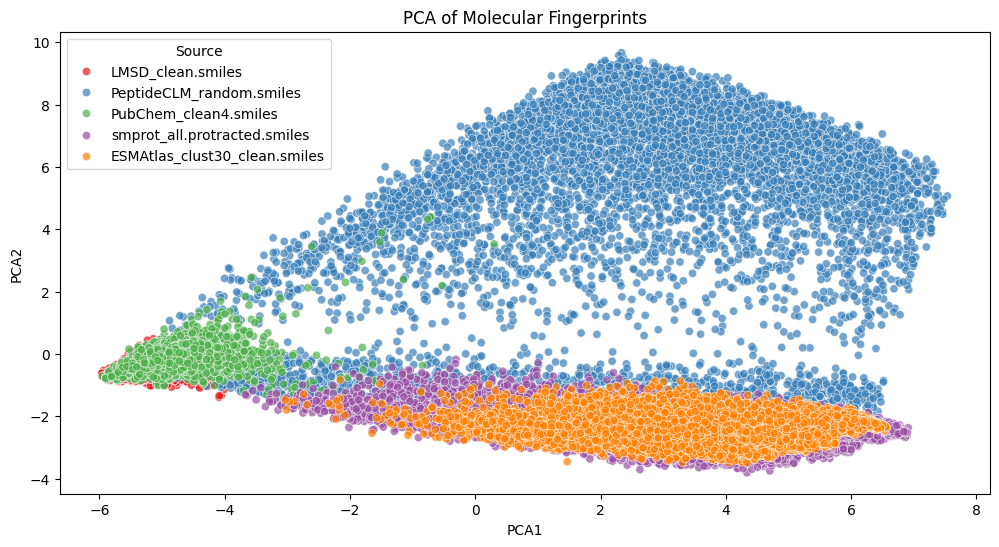

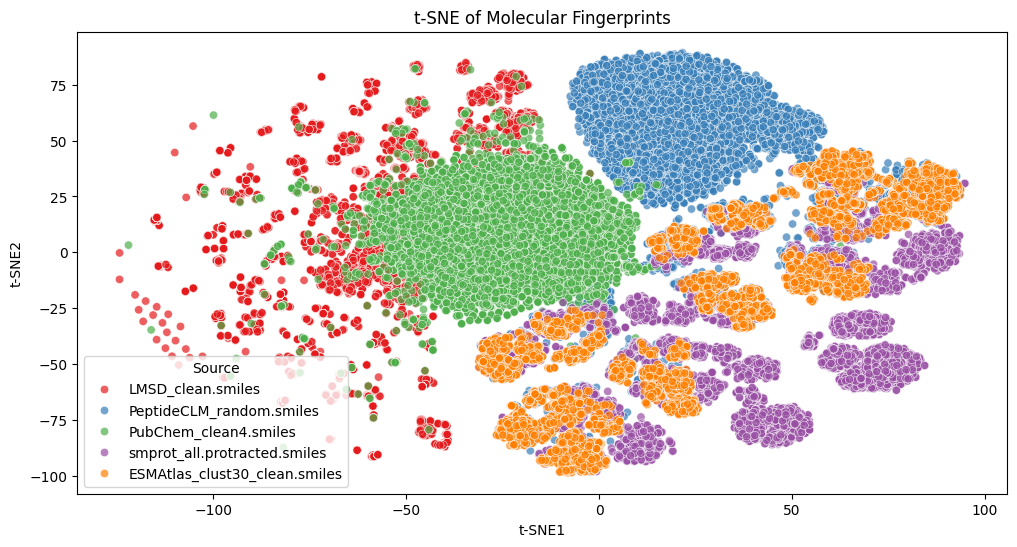

In [15]:
# generate molecular fingerprints using RDKit
from rdkit import Chem
from rdkit.Chem import rdFingerprintGenerator
from tqdm import tqdm

def generate_fingerprints(smiles_list):
    fingerprints = []
    mfpgen = rdFingerprintGenerator.GetMorganGenerator(radius=2, fpSize=2048)
    # Generate fingerprints for each SMILES
    # Using a generator to handle large lists efficiently
    for smile in tqdm(smiles_list, desc="Generating fingerprints"):
        mol = Chem.MolFromSmiles(smile)
        if mol is not None:
            fp = mfpgen.GetFingerprint(mol)
            fingerprints.append(fp)
        else:
            fingerprints.append(None)
    return fingerprints

# Generate fingerprints 
df['fingerprints'] = generate_fingerprints(df['smiles'].tolist())

# Remove rows with None fingerprints
df = df[df['fingerprints'].notnull()]

# Convert fingerprints to a numpy array
fingerprints = np.array([list(fp) for fp in df['fingerprints']])
# Perform PCA
pca = PCA(n_components=2)
pca_result = pca.fit_transform(fingerprints)
# Perform t-SNE
tsne = TSNE(n_components=2, random_state=42, perplexity=30)
tsne_result = tsne.fit_transform(fingerprints)

# Create a DataFrame for PCA and t-SNE results
pca_df = pd.DataFrame(pca_result, columns=['PCA1', 'PCA2'])
tsne_df = pd.DataFrame(tsne_result, columns=['t-SNE1', 't-SNE2'])

# Add source column to PCA and t-SNE DataFrames
pca_df['source'] = df['source'].values
tsne_df['source'] = df['source'].values

# Plot PCA results
plt.figure(figsize=(12, 6))
sns.scatterplot(data=pca_df, x='PCA1', y='PCA2', hue='source', palette='Set1', alpha=0.7)
plt.title('PCA of Molecular Fingerprints')
plt.xlabel('PCA1')
plt.ylabel('PCA2')
plt.legend(title='Source')
plt.savefig('pca_molecular_fingerprints.png', dpi=300)
plt.show()

# Plot t-SNE results
plt.figure(figsize=(12, 6))
sns.scatterplot(data=tsne_df, x='t-SNE1', y='t-SNE2', hue='source', palette='Set1', alpha=0.7)
plt.title('t-SNE of Molecular Fingerprints')
plt.xlabel('t-SNE1')
plt.ylabel('t-SNE2')
plt.legend(title='Source')
plt.savefig('tsne_molecular_fingerprints.png', dpi=300)
plt.show()


In [ ]:
# save smiles, source, PCA1, PCA2, t-SNE1, t-SNE2 to a csv file
output_df = pd.DataFrame({
    'smiles': df['smiles'].values,
    'source': df['source'].values,
    'PCA1': pca_df['PCA1'].values,
    'PCA2': pca_df['PCA2'].values,
    't-SNE1': tsne_df['t-SNE1'].values,
    't-SNE2': tsne_df['t-SNE2'].values
})

output_df.to_csv('molecular_fingerprints_pca_tsne.csv', index=False)

/tmp/ipykernel_1150555/1881011699.py:37: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title='Data source', loc='lower right')


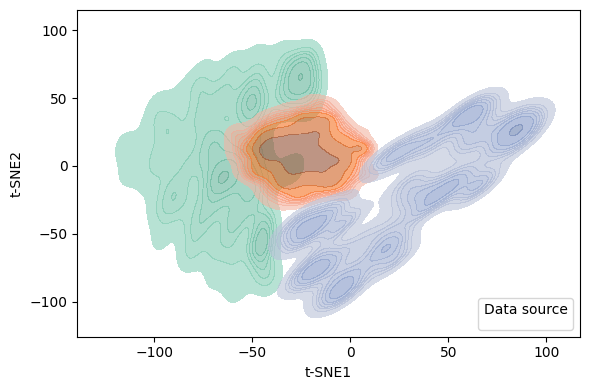

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# load the csv file
output_df = pd.read_csv('molecular_fingerprints_pca_tsne.csv')

# rename source values from file names to more readable names
source_mapping = {
    'LMSD_clean.smiles': 'LMSD',
    'PeptideCLM_random.smiles': 'Cyclic Peptides',
    'PubChem_clean4.smiles': 'PubChem',
    'smprot_all.protracted.smiles': 'Protracted Peptides',
    'ESMAtlas_clust30_clean.smiles': 'ESMAtlas'
}

# map source values to more readable names
output_df['source'] = output_df['source'].map(source_mapping)

# remove smprot_all.protracted.smiles
output_df = output_df[output_df['source'] != 'Protracted Peptides']
# remove PeptideCLM_random.smiles
output_df = output_df[output_df['source'] != 'Cyclic Peptides']


# plot PCA results
plt.figure(figsize=(4, 4))
# sns.scatterplot(data=output_df, x='t-SNE1', y='t-SNE2', hue='source', palette='Set1', alpha=1, )
# make density plot
sns.kdeplot(data=output_df, x='t-SNE1', y='t-SNE2', hue='source', fill=True, alpha=0.6, palette='Set2', thresh=0.05)
# add title and labels
# plt.title('t-SNE of Molecular Fingerprints')
plt.xlabel('t-SNE1')
plt.ylabel('t-SNE2')

# place legend in lower right without changing it
plt.legend(title='Data source', loc='lower right')

# tight layout
plt.tight_layout()

#save
plt.savefig('tsne_molecular_fingerprints_scatter.png', dpi=300)

# plt.show()


Generating fingerprints:  32%|███▏      | 9678/30000 [00:02<00:05, 3883.84it/s][19:13:20] Explicit valence for atom # 53 C, 5, is greater than permitted
[19:13:20] Explicit valence for atom # 79 C, 6, is greater than permitted
[19:13:20] Can't kekulize mol.  Unkekulized atoms: 1 2 3 4 40 42 43 44 51 52 53
Generating fingerprints:  39%|███▉      | 11773/30000 [00:02<00:03, 5034.17it/s][19:13:20] Explicit valence for atom # 39 C, 6, is greater than permitted
[19:13:20] Explicit valence for atom # 47 N, 6, is greater than permitted
[19:13:20] Explicit valence for atom # 21 F, 2, is greater than permitted
Generating fingerprints:  41%|████      | 12349/30000 [00:03<00:03, 5251.40it/s][19:13:20] Explicit valence for atom # 27 C, 5, is greater than permitted
[19:13:20] Explicit valence for atom # 11 N, 5, is greater than permitted
[19:13:20] Explicit valence for atom # 7 H, 2, is greater than permitted
[19:13:20] Explicit valence for atom # 17 C, 5, is greater than permitted
[19:13:20] Expli

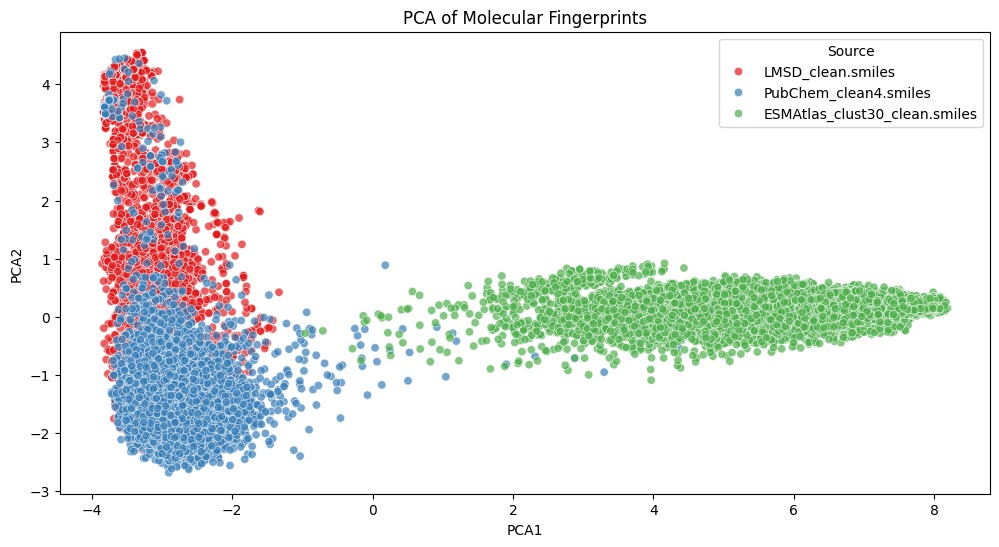

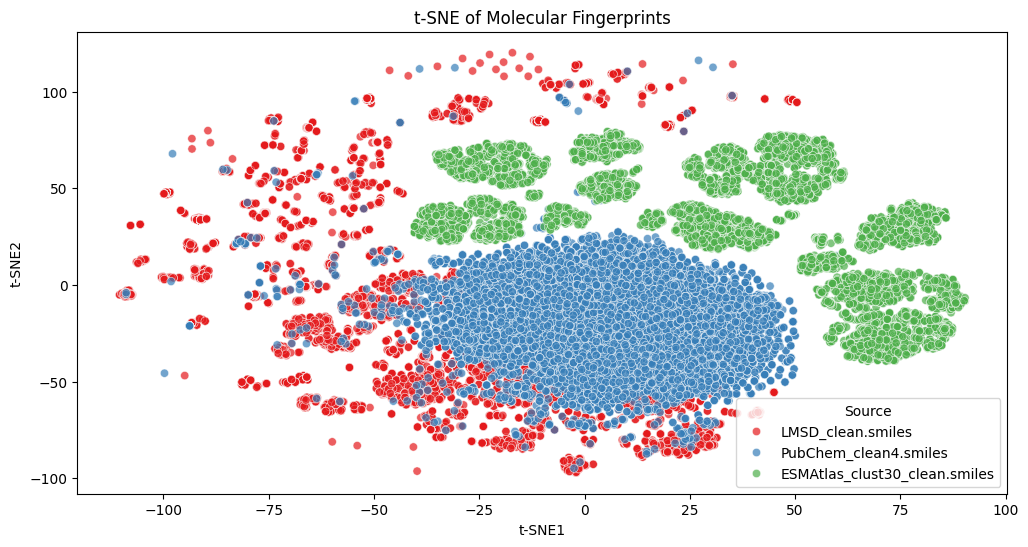

In [18]:
# I want to vizualize my pretraining data using t-SNE and PCA.
import pandas as pd
import numpy as np
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns

# parquet
# take 10k randomly from each file
files = [
    'LMSD_clean.smiles',
    # 'PeptideCLM_random.smiles',
    'PubChem_clean4.smiles',
    # 'smprot_all.protracted.smiles',
    'ESMAtlas_clust30_clean.smiles'
]

data = []
for file in files:
    # read in text csv file
    df = pd.read_csv(file, header=None, names=['smiles'])
    # remove rows where df['smiles'] = 'smiles' 
    df = df[df['smiles'] != 'smiles']
    # take 10k randomly
    df = df.sample(n=10000, random_state=10)
    # add source column
    df['source'] = file
    data.append(df)

# Concatenate all dataframes
df = pd.concat(data, ignore_index=True)


# generate molecular fingerprints using RDKit
from rdkit import Chem
from rdkit.Chem import rdFingerprintGenerator
from tqdm import tqdm

def generate_fingerprints(smiles_list):
    fingerprints = []
    mfpgen = rdFingerprintGenerator.GetMorganGenerator(radius=2, fpSize=1024)
    # Generate fingerprints for each SMILES
    # Using a generator to handle large lists efficiently
    for smile in tqdm(smiles_list, desc="Generating fingerprints"):
        mol = Chem.MolFromSmiles(smile)
        if mol is not None:
            fp = mfpgen.GetFingerprint(mol)
            fingerprints.append(fp)
        else:
            fingerprints.append(None)
    return fingerprints

# Generate fingerprints
df['fingerprints'] = generate_fingerprints(df['smiles'].tolist())

# Remove rows with None fingerprints
df = df[df['fingerprints'].notnull()]

# Convert fingerprints to a numpy array
fingerprints = np.array([list(fp) for fp in df['fingerprints']])
# Perform PCA
pca = PCA(n_components=2)
pca_result = pca.fit_transform(fingerprints)
# Perform t-SNE
tsne = TSNE(n_components=2, random_state=42, perplexity=30)
tsne_result = tsne.fit_transform(fingerprints)

# Create a DataFrame for PCA and t-SNE results
pca_df = pd.DataFrame(pca_result, columns=['PCA1', 'PCA2'])
tsne_df = pd.DataFrame(tsne_result, columns=['t-SNE1', 't-SNE2'])

# Add source column to PCA and t-SNE DataFrames
pca_df['source'] = df['source'].values
tsne_df['source'] = df['source'].values

# Plot PCA results
plt.figure(figsize=(12, 6))
sns.scatterplot(data=pca_df, x='PCA1', y='PCA2', hue='source', palette='Set1', alpha=0.7)
plt.title('PCA of Molecular Fingerprints')
plt.xlabel('PCA1')
plt.ylabel('PCA2')
plt.legend(title='Source')
plt.savefig('pca_molecular_fingerprints.png', dpi=300)
plt.show()

# Plot t-SNE results
plt.figure(figsize=(12, 6))
sns.scatterplot(data=tsne_df, x='t-SNE1', y='t-SNE2', hue='source', palette='Set1', alpha=0.7)
plt.title('t-SNE of Molecular Fingerprints')
plt.xlabel('t-SNE1')
plt.ylabel('t-SNE2')
plt.legend(title='Source')
plt.savefig('tsne_molecular_fingerprints.png', dpi=300)
plt.show()


In [21]:
# df with PCA1, PCA2, t-SNE1, t-SNE2, and source
output_df = pd.DataFrame({
    'smiles': df['smiles'].values,
    'source': tsne_df['source'].values,
    'PCA1': pca_df['PCA1'].values,
    'PCA2': pca_df['PCA2'].values,
    't-SNE1': tsne_df['t-SNE1'].values,
    't-SNE2': tsne_df['t-SNE2'].values
})

output_df.to_csv('molecular_fingerprints_pca_tsne_v2.csv', index=False)

In [22]:
output_df

,smiles,source,PCA1,PCA2,t-SNE1,t-SNE2
0,CC(C)CCC[C@@H](C)[C@H]1CC[C@H]2C3=C[C@H](O)[C@...,LMSD,-2.939130,-1.062705,20.806126,-85.918655
1,CCCCC/C=C\C/C=C\C/C=C\CCCCCCC(=O)OC[C@@H](COC(...,LMSD,-3.813956,3.605616,-92.139992,-20.389769
2,COc1c(-c2ccc(O)c(O)c2)oc2cc(O[C@@H]3O[C@H](CO)...,LMSD,-3.106417,-1.754614,-63.131046,-21.120464
3,CCCCC/C=C\CCCCCCCC(=O)O[C@H](CO/C=C\CCCCCCCCCC...,LMSD,-3.711639,3.520743,-2.111855,113.655609
4,COc1cc(-c2oc3cc(O)cc(O)c3c(=O)c2O[C@@H]2O[C@H]...,LMSD,-3.076178,-1.616981,-66.774422,-20.487179
...,...,...,...,...,...,...
29950,CC[C@H](C)[C@H](NC(=O)[C@H](CC(C)C)NC(=O)[C@@H...,ESMAtlas,4.132185,0.133747,-27.514086,64.045380
29951,CC[C@H](C)[C@H](NC(=O)[C@H](CC(N)=O)NC(=O)[C@H...,ESMAtlas,4.305639,0.237176,-35.223198,36.025799
29952,CC[C@H](C)[C@H](NC(=O)CNC(=O)CNC(=O)[C@H](CC(C...,ESMAtlas,6.966992,0.002564,33.550076,69.881889
29953,CC[C@H](C)[C@H](NC(=O)[C@H](C)NC(=O)[C@H](C)NC...,ESMAtlas,5.864990,0.255300,6.214243,77.188774


In [20]:
# rename source values from file names to more readable names
source_mapping = {
    'LMSD_clean.smiles': 'LMSD',
    'PeptideCLM_random.smiles': 'Cyclic Peptides',
    'PubChem_clean4.smiles': 'PubChem',
    'smprot_all.protracted.smiles': 'Protracted Peptides',
    'ESMAtlas_clust30_clean.smiles': 'ESMAtlas'
}

# map source values to more readable names
tsne_df['source'] = tsne_df['source'].map(source_mapping)

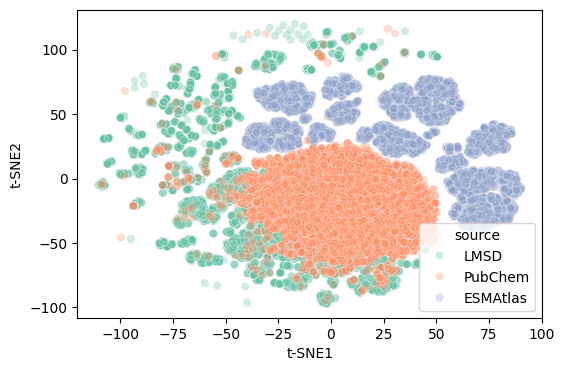

In [ ]:
# read csv file
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

tsne_df = pd.read_csv('molecular_fingerprints_pca_tsne_v2.csv')

# Plot t-SNE results
plt.figure(figsize=(6, 4))

# sns.scatterplot(data=tsne_df, x='t-SNE1', y='t-SNE2', hue='source', palette='Set2', alpha=0.3)
# density plot
sns.kdeplot(data=tsne_df, x='t-SNE1', y='t-SNE2', hue='source', fill=True, thresh=0.05, levels=10, alpha=0.6, palette='Set2')
# plt.title('t-SNE of Molecular Fingerprints')
plt.xlabel('t-SNE1')
plt.ylabel('t-SNE2')
plt.savefig('tsne_molecular_fingerprints.png', dpi=300)
plt.show()

In [ ]:
# take 1000 from each source, embed with ChemBERTa-2 77M MTR
from transformers import AutoTokenizer, AutoModel
import torch

# Load ChemBERTa-2 tokenizer and model
tokenizer = AutoTokenizer.from_pretrained("DeepChem/ChemBERTa-77M-MTR")
model = AutoModel.from_pretrained("DeepChem/ChemBERTa-77M-MTR")

def embed_smiles(smiles_list):
    embeddings = []
    for smile in tqdm(smiles_list, desc="Embedding SMILES with ChemBERTa-2"):
        inputs = tokenizer(smile, return_tensors='pt', padding=True, truncation=True)
        with torch.no_grad():
            outputs = model(**inputs)
        # Use the mean of the last hidden state as the embedding
        embedding = outputs.last_hidden_state.mean(dim=1).squeeze().numpy()
        embeddings.append(embedding)
    return np.array(embeddings)
# Take 1000 from each source
sampled_df = df.groupby('source').apply(lambda x: x.sample(n=1000, random_state=42)).reset_index(drop=True)

# Embed the SMILES strings
sampled_df['embeddings'] = sampled_df['smiles'].apply(lambda x: embed_smiles([x]))

# Convert embeddings to a numpy array
embeddings = np.array([list(fp) for fp in sampled_df['embeddings']])


Some weights of RobertaModel were not initialized from the model checkpoint at DeepChem/ChemBERTa-77M-MTR and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/tmp/ipykernel_9022/2007401313.py:20: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  sampled_df = df.groupby('source').apply(lambda x: x.sample(n=1000, random_state=42)).reset_index(drop=True)
Embedding SMILES with ChemBERTa-2: 100%|██████████| 1/1 [00:00<00:00, 60.13it/s]


ValueError: Found array with dim 3, while dim <= 2 is required by PCA.

In [23]:
# embeddings has shape (5000, 1, 384), but PCA expects (n_samples, n_features)
# Remove the singleton dimension
embeddings_2d = embeddings.squeeze(axis=1)  # shape becomes (5000, 384)


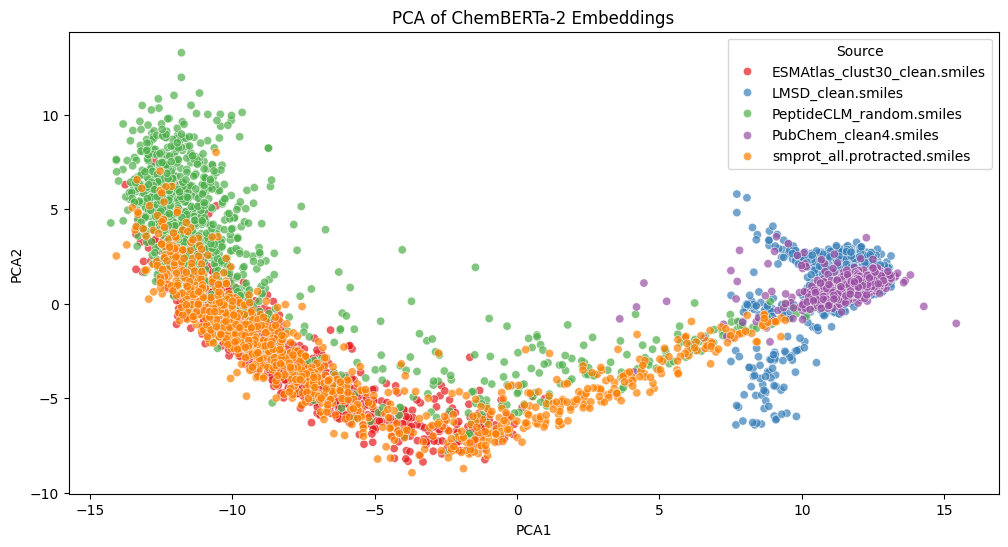

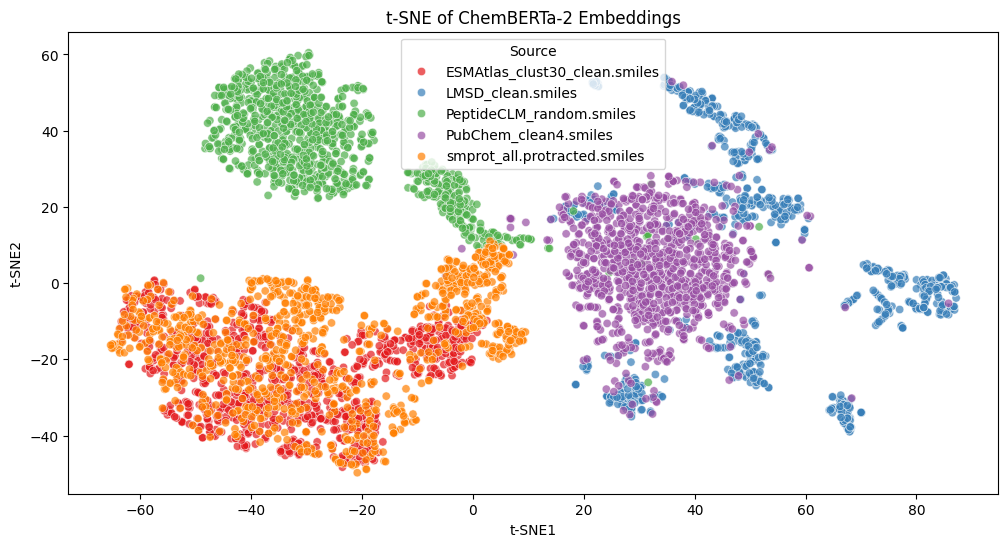

In [24]:
# Perform PCA on the embeddings
pca = PCA(n_components=2)
pca_result = pca.fit_transform(embeddings_2d)
# Perform t-SNE on the embeddings
tsne = TSNE(n_components=2, random_state=42, perplexity=30)
tsne_result = tsne.fit_transform(embeddings_2d)

# Create a DataFrame for PCA and t-SNE results
pca_df = pd.DataFrame(pca_result, columns=['PCA1', 'PCA2'])
tsne_df = pd.DataFrame(tsne_result, columns=['t-SNE1', 't-SNE2'])
# Add source column to PCA and t-SNE DataFrames
pca_df['source'] = sampled_df['source'].values
tsne_df['source'] = sampled_df['source'].values
# Plot PCA results
plt.figure(figsize=(12, 6))
sns.scatterplot(data=pca_df, x='PCA1', y='PCA2', hue='source', palette='Set1', alpha=0.7)
plt.title('PCA of ChemBERTa-2 Embeddings')
plt.xlabel('PCA1')
plt.ylabel('PCA2')
plt.legend(title='Source')
plt.savefig('pca_chemberta_embeddings.png', dpi=300)
plt.show()

# Plot t-SNE results
plt.figure(figsize=(12, 6))
sns.scatterplot(data=tsne_df, x='t-SNE1', y='t-SNE2', hue='source', palette='Set1', alpha=0.7)
plt.title('t-SNE of ChemBERTa-2 Embeddings')
plt.xlabel('t-SNE1')
plt.ylabel('t-SNE2')
plt.legend(title='Source')
plt.savefig('tsne_chemberta_embeddings.png', dpi=300)
plt.show()



In [27]:
import torch
# make a mask of [100, 150]
mask = torch.ones(100, 150, dtype=torch.bool)
print(mask[0, 0])
mask[0,0] = False
print(mask[0, 0])
print(mask.shape)

seq_len = mask.shape[1]

mask = mask[:, None, None, :seq_len].expand(100, 1, seq_len, seq_len)  # expands to (batch, 1, seqlen, seqlen)

print(mask[0,0])
print(mask[0])
mask.shape

tensor(True)
tensor(False)
torch.Size([100, 150])
tensor([[False,  True,  True,  ...,  True,  True,  True],
        [False,  True,  True,  ...,  True,  True,  True],
        [False,  True,  True,  ...,  True,  True,  True],
        ...,
        [False,  True,  True,  ...,  True,  True,  True],
        [False,  True,  True,  ...,  True,  True,  True],
        [False,  True,  True,  ...,  True,  True,  True]])
tensor([[[False,  True,  True,  ...,  True,  True,  True],
         [False,  True,  True,  ...,  True,  True,  True],
         [False,  True,  True,  ...,  True,  True,  True],
         ...,
         [False,  True,  True,  ...,  True,  True,  True],
         [False,  True,  True,  ...,  True,  True,  True],
         [False,  True,  True,  ...,  True,  True,  True]]])


torch.Size([100, 1, 150, 150])

In [15]:
pad_token_id = 0

input_ids = [[1, 2, 3, 4, 5, pad_token_id, pad_token_id, pad_token_id] for _ in range(5)]  # Example input IDs

input_ids = torch.tensor(input_ids, dtype=torch.long)
pad_mask = (input_ids != pad_token_id) # (B, T)
pad_mask


tensor([[ True,  True,  True,  True,  True, False, False, False],
        [ True,  True,  True,  True,  True, False, False, False],
        [ True,  True,  True,  True,  True, False, False, False],
        [ True,  True,  True,  True,  True, False, False, False],
        [ True,  True,  True,  True,  True, False, False, False]])

In [34]:
import torch
from torch import nn

device = 'cpu'

# og shape (32, 128, 512)

# split into 8 heads of shape (32, 8, 128, 64)

query = torch.rand(32, 8, 128, 64, dtype=torch.float16, device=device)
key = torch.rand(32, 8, 128, 64, dtype=torch.float16, device=device)
value = torch.rand(32, 8, 128, 64, dtype=torch.float16, device=device)

attn_mask = torch.rand(32, 128, dtype=torch.float16, device=device)

attn_mask = attn_mask[:, None, None, :].expand(32, 1, 128, 128)  # expands to (batch, 1, seqlen, seqlen)
print(attn_mask.shape)

attention_output = nn.functional.scaled_dot_product_attention(
    query=query,
    key=key,
    value=value,
    attn_mask=attn_mask
)



torch.Size([32, 1, 128, 128])


In [29]:
import torch
from torch import nn

device = 'cpu'

# og shape (32, 128, 512)

# split into 8 heads of shape (32, 8, 128, 64)
mha = nn.MultiheadAttention(512, 8, batch_first=True, bias=False).to(dtype=torch.float16, device=device)

query = torch.rand(32, 8, 128, 64, dtype=torch.float16, device=device)
key = torch.rand(32, 8, 128, 64, dtype=torch.float16, device=device)
value = torch.rand(32, 8, 128, 64, dtype=torch.float16, device=device)

attn_mask = torch.rand(32, 128, dtype=torch.float16, device=device)

query = query.view(32, 128, 64*8)
key = key.view(32, 128, 64*8)
value = value.view(32, 128, 64*8)

print(key.shape)

attention_output = mha(
    query=query,
    key=key,
    value=value,
    key_padding_mask=attn_mask
)[0]



torch.Size([32, 128, 512])


In [30]:
attention_output.shape  # Should be (32, 8, 128, 64)

out_proj = nn.Linear(64*8, 64*8, bias=False)

attention_output = attention_output.transpose(1, 2).contiguous().view(32, 128, 512)  # Reshape to (batch, seq_len, embed_dim)

# fix data type for out_proj
out_proj = out_proj.to(torch.float16)

projection_output = out_proj(attention_output)

projection_output.shape  # Should be (32, 128, 512)

torch.Size([32, 128, 512])

In [1]:
import torch

mask = torch.tensor([[1, 1, 1, 0, 0], [1, 1, 1, 1, 1]]).unsqueeze(1).expand(-1, 5, -1)
mask.shape

mask.unbind(1)

(tensor([[1, 1, 1, 0, 0],
         [1, 1, 1, 1, 1]]),
 tensor([[1, 1, 1, 0, 0],
         [1, 1, 1, 1, 1]]),
 tensor([[1, 1, 1, 0, 0],
         [1, 1, 1, 1, 1]]),
 tensor([[1, 1, 1, 0, 0],
         [1, 1, 1, 1, 1]]),
 tensor([[1, 1, 1, 0, 0],
         [1, 1, 1, 1, 1]]))

In [16]:
import torch

mask = torch.tensor([[1, 1, 1, 0, 0], [1, 1, 1, 1, 1]]).unsqueeze(1).expand(-1, 1, -1)
mask = mask.to(torch.bool)
print(mask)

mask = (torch.zeros_like(mask, dtype=float).masked_fill_(mask, float("-inf")))
mask

tensor([[[ True,  True,  True, False, False]],

        [[ True,  True,  True,  True,  True]]])


tensor([[[-inf, -inf, -inf, 0., 0.]],

        [[-inf, -inf, -inf, -inf, -inf]]], dtype=torch.float64)

In [18]:
import pandas as pd

# Load the dataset
df = pd.read_csv('../finetuning/perm_external.csv')
df.columns

Index(['SMILES', 'value', 'fold'], dtype='object')

In [ ]:
import pandas as pd
from rdkit import Chem
from rdkit.Chem import Descriptors
import numpy as np
from sklearn.preprocessing import StandardScaler

# Load the dataset
df = pd.read_csv('../finetuning/perm_external.csv')

def smiles_to_rdkit(smiles):
    mol = Chem.MolFromSmiles(smiles)
    return np.array([float(x[1](mol)) for x in Descriptors._descList if x[0]!='Ipc'])

# Convert all SMILES to descriptors
descriptors = np.stack(df['SMILES'].apply(smiles_to_rdkit).values)

# Normalize
scaler = StandardScaler()
normalized_desc = scaler.fit_transform(descriptors)

# Save both the normalized descriptors and the scaler for future use
np.save('../finetuning/perm_normalized_rdkit_descriptors.npy', normalized_desc)
np.save('../finetuning/perm_scaler.npy', scaler)

# Later, to load and use:
# loaded_desc = np.load('../finetuning/perm_normalized_rdkit_descriptors.npy')  # Each row is one SMILES
# scaler = np.load('../finetuning/perm_scaler.npy', allow_pickle=True)

In [17]:
import pandas as pd
from rdkit import Chem
from rdkit.Chem import AllChem
import numpy as np
from sklearn.preprocessing import StandardScaler

# Load the dataset
df = pd.read_csv('../finetuning/perm_external.csv')

def smiles_to_morgan(smiles, radius=2, nBits=2048):
    mol = Chem.MolFromSmiles(smiles)
    fingerprint = AllChem.GetMorganFingerprintAsBitVect(mol, radius, nBits)
    return np.array(fingerprint)

# Convert all SMILES to Morgan fingerprints
fingerprints = np.stack(df['SMILES'].apply(smiles_to_morgan).values)

# Note: Normalization might not be necessary for Morgan fingerprints 
# since they're already binary (0/1), but including it just in case
scaler = StandardScaler()
normalized_fp = scaler.fit_transform(fingerprints)

# Save both the normalized fingerprints and the scaler
np.save('../finetuning/perm_normalized_morgan_fps.npy', normalized_fp)
np.save('../finetuning/perm_morgan_scaler.npy', scaler)

# Later, to load and use:
# loaded_fp = np.load('../finetuning/perm_normalized_morgan_fps.npy')  # Each row is one SMILES
# scaler = np.load('../finetuning/perm_morgan_scaler.npy', allow_pickle=True)

[19:12:23] DEPRECATION WARNING: please use MorganGenerator
[19:12:23] DEPRECATION WARNING: please use MorganGenerator
[19:12:23] DEPRECATION WARNING: please use MorganGenerator
[19:12:23] DEPRECATION WARNING: please use MorganGenerator
[19:12:23] DEPRECATION WARNING: please use MorganGenerator
[19:12:23] DEPRECATION WARNING: please use MorganGenerator
[19:12:23] DEPRECATION WARNING: please use MorganGenerator
[19:12:23] DEPRECATION WARNING: please use MorganGenerator
[19:12:23] DEPRECATION WARNING: please use MorganGenerator
[19:12:23] DEPRECATION WARNING: please use MorganGenerator
[19:12:23] DEPRECATION WARNING: please use MorganGenerator
[19:12:23] DEPRECATION WARNING: please use MorganGenerator
[19:12:23] DEPRECATION WARNING: please use MorganGenerator
[19:12:23] DEPRECATION WARNING: please use MorganGenerator
[19:12:23] DEPRECATION WARNING: please use MorganGenerator
[19:12:23] DEPRECATION WARNING: please use MorganGenerator
[19:12:23] DEPRECATION WARNING: please use MorganGenerat

In [4]:
from transformers import AutoTokenizer

a_tokenizer = AutoTokenizer.from_pretrained("DeepChem/SmilesTokenizer_PubChem_1M")
k_tokenizer = AutoTokenizer.from_pretrained("aaronfeller/PeptideMTR")


In [2]:
import pandas as pd

df = pd.read_csv('esm_atlas/clust30_100aa_2.csv')
df.columns

# select 10000 random rows, take the SMILES column and make a list
smiles_list = df.sample(n=10000, random_state=42)['SMILES'].tolist()
print(smiles_list[:5])

['CC[C@H](C)[C@H](NC(=O)[C@H](C)NC(=O)[C@H](CCSC)NC(=O)[C@H](CC(=O)O)NC(=O)[C@@H](NC(=O)[C@H](CCC(=O)O)NC(=O)[C@H](CCCCN)NC(=O)[C@H](Cc1ccc(O)cc1)NC(=O)[C@@H](NC(=O)[C@H](C)NC(=O)[C@H](CCC(=O)O)NC(=O)CNC(=O)[C@H](CC(C)C)NC(=O)[C@H](CC(=O)O)NC(=O)[C@H](CC(C)C)NC(=O)[C@H](CC(C)C)NC(=O)[C@@H]1CCCN1C(=O)[C@H](CCC(=O)O)NC(=O)[C@H](CCC(=O)O)NC(=O)CNC(=O)[C@H](CCC(N)=O)NC(=O)[C@H](CCSC)NC(=O)[C@H](CC(C)C)NC(=O)[C@H](CCC(N)=O)NC(=O)[C@H](CC(N)=O)NC(=O)[C@H](C)NC(=O)[C@H](CCCNC(=N)N)NC(=O)[C@H](CCCCN)NC(=O)CNC(=O)[C@@H](NC(=O)[C@@H](NC(=O)[C@H](Cc1c[nH]cn1)NC(=O)[C@H](CO)NC(=O)[C@H](CC(C)C)NC(=O)[C@H](CC(C)C)NC(=O)[C@H](Cc1ccc(O)cc1)NC(=O)[C@H](CCCNC(=N)N)NC(=O)[C@H](CC(N)=O)NC(=O)[C@H](CC(N)=O)NC(=O)[C@H](CCC(=O)O)NC(=O)[C@@H](NC(=O)[C@H](CCCNC(=N)N)NC(=O)[C@H](C)NC(=O)[C@H](CC(C)C)NC(=O)[C@H](C)NC(=O)[C@H](CCCCN)NC(=O)[C@@H](NC(=O)[C@@H](NC(=O)[C@H](CO)NC(=O)[C@H](CCCCN)NC(=O)[C@H](CCC(=O)O)NC(=O)[C@H](CC(C)C)NC(=O)[C@H](CCCNC(=N)N)NC(=O)[C@H](CC(=O)O)NC(=O)[C@@H](NC(=O)[C@H](CCSC)NC(=O)[C@H]

In [3]:
# read PubChem_clean4.smiles and take 10000 random SMILES
smiles_list2 = []
with open('PubChem_clean4.smiles', 'r') as f:
    for line in f:
        smile = line.strip()
        smiles_list2.append(smile)
        if len(smiles_list2) >= 10000:
            break
print(smiles_list2[:5])



['*C(C)n1cccc1[N+](=O)[O-]', 'B#C/C(C)=C/C=C(/N)C=C', 'B#C/C(N)=C(/C)c1cccc(/C(C=C)=C/c2ccccc2C)c1', 'B#C/C(N)=C(\\N)N(C)c1ccc(NC(=O)OC(C)(C)C)cc1', 'B#C/C(NC)=C(/C)c1cccc(CCc2cccc3c2CCCC3)c1']


In [6]:
# store tokenized SMILES
atomistic_list = []
kmer_list = []

list_of_SMILES = smiles_list

for smile in list_of_SMILES:
    a_tokenized = a_tokenizer(smile, padding=False, truncation=False, return_tensors="pt")
    k_tokenized = k_tokenizer(smile, padding=False, truncation=False, return_tensors="pt")
    atomistic_list.append(a_tokenized)
    kmer_list.append(k_tokenized)


a_lengths = [len(item['input_ids'][0]) for item in atomistic_list]
k_lengths = [len(item['input_ids'][0]) for item in kmer_list]



In [8]:
# save lengths to a csv file
lengths_df = pd.DataFrame({
    'SMILES': list_of_SMILES,
    'Atomistic_Length': a_lengths,
    'Kmer_Length': k_lengths
})

lengths_df.to_csv('esm_atlas_token_lengths.csv', index=False)


Average A:860.3894
Average K:312.241
Compression Ratio (K/A):0.3629066094956539


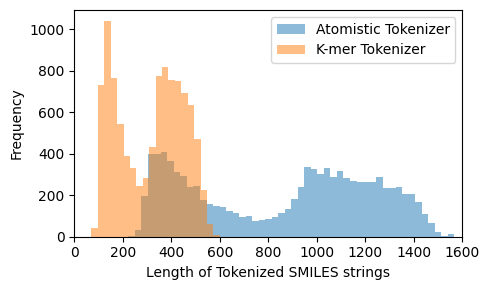

In [9]:
# plot distribution of lengths for two tokenizers using input_ids
import matplotlib.pyplot as plt

plt.figure(figsize=(5, 3))
plt.hist(a_lengths, bins=50, alpha=0.5, label='Atomistic Tokenizer')
plt.hist(k_lengths, bins=20, alpha=0.5, label='K-mer Tokenizer')
plt.xlabel('Length of Tokenized SMILES strings')
plt.ylabel('Frequency')
plt.xlim(0, 1600)
plt.legend()
plt.tight_layout()
# save figure
plt.savefig('tokenizer_length_distribution_peptides.png', dpi=300)
# plt.show()

# take average of each group and print it and a compression ratio between the two

avg_a = sum(a_lengths) / len(a_lengths) if a_lengths else 0
avg_k = sum(k_lengths) / len(k_lengths) if k_lengths else 0

print('Average A:' + str(avg_a))
print('Average K:' + str(avg_k))
print('Compression Ratio (K/A):' + str(avg_k / avg_a) if avg_k else 'Inf')  

In [10]:
# store tokenized SMILES
atomistic_list = []
kmer_list = []

list_of_SMILES = smiles_list2

for smile in list_of_SMILES:
    a_tokenized = a_tokenizer(smile, padding=False, truncation=False, return_tensors="pt")
    k_tokenized = k_tokenizer(smile, padding=False, truncation=False, return_tensors="pt")
    atomistic_list.append(a_tokenized)
    kmer_list.append(k_tokenized)

a_lengths = [len(item['input_ids'][0]) for item in atomistic_list]
k_lengths = [len(item['input_ids'][0]) for item in kmer_list]

# save lengths to a csv file
lengths_df = pd.DataFrame({
    'SMILES': list_of_SMILES,
    'Atomistic_Length': a_lengths,
    'Kmer_Length': k_lengths
})

lengths_df.to_csv('pubchem_token_lengths.csv', index=False)


Average A:36.0498
Average K:22.4274
Compression Ratio (K/A):0.6221227302231913


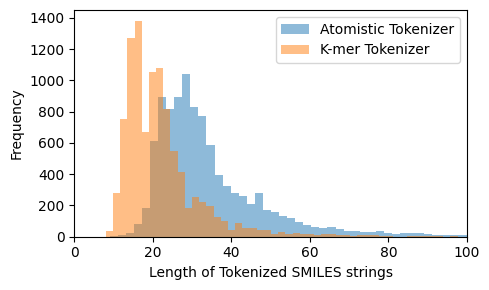

In [ ]:
# plot distribution of lengths for two tokenizers using input_ids
# load dataset


ea_a_lengths_df = pd.read_csv('esm_atlas_token_lengths.csv')
ea_a_lengths = lengths_df['Atomistic_Length'].tolist()
ea_k_lengths = lengths_df['Kmer_Length'].tolist()

pc_lengths_df = pd.read_csv('pubchem_token_lengths.csv')
pc_a_lengths = lengths_df['Atomistic_Length'].tolist()
pc_k_lengths = lengths_df['Kmer_Length'].tolist()

import matplotlib.pyplot as plt

plt.figure(figsize=(5, 3))
plt.hist(a_lengths, bins=200, alpha=0.5, label='Atomistic Tokenizer')
plt.hist(k_lengths, bins=200, alpha=0.5, label='K-mer Tokenizer')
plt.xlabel('Length of Tokenized SMILES strings')
plt.ylabel('Frequency')
plt.xlim(0, 100)
plt.legend()
plt.tight_layout()
plt.savefig('tokenizer_length_distribution_pubchem.png', dpi=300)
# plt.show()

# take average of each group and print it and a compression ratio between the two

avg_a = sum(a_lengths) / len(a_lengths) if a_lengths else 0
avg_k = sum(k_lengths) / len(k_lengths) if k_lengths else 0

print('Average A:' + str(avg_a))
print('Average K:' + str(avg_k))
print('Compression Ratio (K/A):' + str(avg_k / avg_a) if avg_k else 'Inf')  

In [7]:
from huggingface_hub import HfApi

api = HfApi()

repo_id = "aaronfeller/PeptideMTR_pretraining_data"

files_to_push = {
    "test/mixed.parquet": "ARVF_dataset/test_pubchem_esm_lmsd.parquet",
    "train/lipids.parquet": "ARVF_dataset/train_lmsd.parquet",
    "train/small_molecules.parquet": "ARVF_dataset/train_esm.parquet",
    "train/peptides.parquet": "ARVF_dataset/train_pubchem.parquet",
}

for path_in_repo, local_file in files_to_push.items():
    print(f"Uploading {local_file} to {path_in_repo} in repo {repo_id}...")
    api.upload_file(
        path_or_fileobj=local_file,
        path_in_repo=path_in_repo,
        repo_id=repo_id,
        repo_type="dataset",
        commit_message=f"Add {path_in_repo}"
    )

Uploading ARVF_dataset/test_pubchem_esm_lmsd.parquet to test/mixed.parquet in repo aaronfeller/PeptideMTR_pretraining_data...
Uploading ARVF_dataset/train_lmsd.parquet to train/lipids.parquet in repo aaronfeller/PeptideMTR_pretraining_data...
Uploading ARVF_dataset/train_esm.parquet to train/small_molecules.parquet in repo aaronfeller/PeptideMTR_pretraining_data...
Uploading ARVF_dataset/train_pubchem.parquet to train/peptides.parquet in repo aaronfeller/PeptideMTR_pretraining_data...
